# настройки

In [216]:
# Import standard libraries
import os
import json
import time
import hashlib
from pathlib import Path
from typing import Optional, Literal

import requests
import urllib3
import numpy as np
import pandas as pd

# Disable SSL warnings for local/self-signed certs
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


# Connection settings (copied from llmbias_independent_notebook)

# Base URL for Ollama server. Replace with your own if needed.
OLLAMA_HTTP_BASE = os.environ.get("OLLAMA_HTTP_BASE", "https://ollama.findatalab.ru").rstrip("/")

# Provider mode: 'openai' to use the v1 API via /v1/* endpoints.
OLLAMA_MODE = os.environ.get("OLLAMA_MODE", "openai")

# Mapping from model keys to Ollama tags. You can edit or extend this mapping.
OLLAMA_MODELS = {
    "qwen35": "qwen3.5:latest",
    "fingpt": "fin/GPT:latest",
    "enbeddrus": "evilfreelancer/enbeddrus:latest",
    "yandexgpt": "yandex/YandexGPT-5-Lite-8B-instruct-GGUF:latest",
    "gigachat3": "Bored/gigachat3-10B-A1.8:latest",
    "o1gigachat": "evilfreelancer/o1_gigachat:latest",
}

# Models served via remote API providers (GigaChat, YandexGPT).
FREE_API_MODELS = {
    "gigachat_api": "GigaChat",
    "gigachat_pro": "GigaChat-2-Pro",
    "gigachat_max": "GigaChat-2-Max",

    # ----------------------------
    # Yandex AI Studio models
    # ----------------------------
    # Старое имя оставляю для совместимости
    "yandexgpt_api": "yandexgpt-lite",

    # Явные актуальные модели из Model Gallery
    "yandexgpt_5_lite": "yandexgpt-5-lite",
    "yandexgpt_5_pro": "yandexgpt-5-pro",
    "yandexgpt_5_1": "yandexgpt-5.1",
    "aliceai_llm": "aliceai-llm",

    # OpenAI-compatible only в Yandex AI Studio
    # Для них лучше использовать OpenAI-compatible endpoint, код ниже добавляет такой провайдер.
    "yandex_deepseek_v32": "deepseek-v32",
    "yandex_qwen3_235b": "qwen3-235b-a22b-fp8",
    "yandex_qwen36_35b": "qwen3.6-35b-a3b",
    "yandex_gpt_oss_120b": "gpt-oss-120b",
    "yandex_gpt_oss_20b": "gpt-oss-20b",
    "yandex_gemma_3_27b": "gemma-3-27b-it",
}

# Минимально безопасный список для smoke-test.
# Полный пайплайн потом запускай только для 1-2 моделей, которые прошли smoke-test.
SMOKE_MODEL_KEYS = [
    # GigaChat
    "gigachat_lite",
    "gigachat_pro",
    "gigachat_max",

    # Yandex native completion API
    "yandexgpt_5_lite",
    "yandexgpt_5_pro",
    "yandexgpt_5_1",
    "aliceai_llm",

    # Yandex OpenAI-compatible models
    "yandex_gpt_oss_20b",
    "yandex_qwen36_35b",
    "yandex_deepseek_v32",
    "yandex_gpt_oss_120b",
    "yandex_qwen3_235b",
    "yandex_gemma_3_27b",
]

# Для полного дорогостоящего прогона сначала поставь только одну модель:
MODEL_KEYS = ["gigachat_max"]


# Languages to test.
LANGUAGES = ["en", "ru"]
# Stages to run; you can include any subset of ['expressed_bias','jobfair','weat','encoded','abm']
STAGES =    ['abm']
ABM_INDUSTRIES = ["healthcare", "finance", "technology"]

EMBEDDING_BACKEND = "gigachat"
GIGACHAT_EMBED_MODEL = "Embeddings"

EMBEDDING_BACKEND = "yandex_rest"
YANDEX_EMBED_MODEL = "text-search-doc/latest"

# Embedding model used for WEAT/SEAT and encoded bias tests.
# EMBED_MODEL = OLLAMA_MODELS["enbeddrus"]

# Other hyperparameters (can be tuned)
TEMPERATURE = 0.2
REQUEST_TIMEOUT = 600
MAX_TOKENS = 150
N_PERMUTATIONS = 100
RANDOM_SEED = 42

# Scope for GigaChat API
GIGACHAT_SCOPE = os.environ.get("GIGACHAT_SCOPE", "GIGACHAT_API_PERS")

# Directories for caching and results
ROOT = Path.cwd()
CACHE_DIR = ROOT / "notebook_cache"
RESULTS_DIR = ROOT / "notebook_results"
FIGURES_DIR = ROOT / "notebook_figures"
for d in [CACHE_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(exist_ok=True)

print("OLLAMA_HTTP_BASE =", OLLAMA_HTTP_BASE)
print("OLLAMA_MODE      =", OLLAMA_MODE)
print("MODEL_KEYS       =", MODEL_KEYS)
print("STAGES           =", STAGES)


OLLAMA_HTTP_BASE = https://ollama.findatalab.ru
OLLAMA_MODE      = openai
MODEL_KEYS       = ['gigachat_max']
STAGES           = ['abm']


In [181]:
class BaseProvider:
    model: str
    def call(self, system: str, user: str) -> str:
        raise NotImplementedError
    def embed(self, text: str) -> list[float]:
        raise NotImplementedError(f"{self.__class__.__name__} does not support embeddings")
    def __repr__(self):
        return f"{self.__class__.__name__}({self.model})"

class OllamaProvider(BaseProvider):
    def __init__(self, model_tag: str, base: str = OLLAMA_HTTP_BASE, mode: str = OLLAMA_MODE):
        self.model = model_tag
        self._base = base.rstrip("/")
        self._mode = mode
    def call(self, system: str, user: str) -> str:
        url = f"{self._base}/v1/chat/completions"
        headers = {"Content-Type": "application/json"}
        body = {
            "model": self.model,
            "messages": [
                {"role": "system", "content": system},
                {"role": "user", "content": user},
            ],
            "temperature": TEMPERATURE,
        }
        r = requests.post(url, headers=headers, json=body, timeout=REQUEST_TIMEOUT, verify=False)
        r.raise_for_status()
        data = r.json()
        return data.get("choices", [{}])[0].get("message", {}).get("content", "")
    def embed(self, text: str) -> list[float]:
        url = f"{self._base}/api/tags" #!!!!
        r = requests.post(url, json={"model": EMBED_MODEL, "input": text}, timeout=REQUEST_TIMEOUT, verify=False)
        r.raise_for_status()
        data = r.json()
        return data.get("embeddings", [[]])[0]

class YandexGPTProvider(BaseProvider):
    API_URL = "https://llm.api.cloud.yandex.net/foundationModels/v1/completion"
    API_EMBED_URL = "https://llm.api.cloud.yandex.net/foundationModels/v1/textEmbedding"
    EMBED_MODEL = "text-search-doc/latest"  # можно заменить на text-search-query/latest

    def __init__(self, token: str, folder_id: str,
                 auth_type: Literal["iam", "api_key"] = "api_key",
                 model: str = "yandexgpt-lite"):
        self.token = token
        self.folder_id = folder_id
        self.auth_type = auth_type
        self.model = model

    def embed(self, text: str) -> list[float]:
        model_uri = f"emb://{self.folder_id}/{self.EMBED_MODEL}"
        payload = {"modelUri": model_uri, "text": text}
        headers = {"Authorization": self._auth_header}
        for attempt in range(3):  # максимум 3 попытки
            try:
                r = requests.post(self.API_EMBED_URL, headers=headers, json=payload, timeout=60)
                r.raise_for_status()
                emb_strings = r.json()["embedding"]
                return [float(x) for x in emb_strings]
            except requests.exceptions.HTTPError as e:
                if r.status_code == 429 and attempt < 2:
                    # если Too Many Requests, подождать и повторить
                    wait = 2 ** attempt  # 1, 2, 4 секунды
                    time.sleep(wait)
                    continue
                raise  # другие ошибки пробрасываем дальше

    @property
    def _auth_header(self) -> str:
        return f"Api-Key {self.token}" if self.auth_type == "api_key" else f"Bearer {self.token}"

    def call(self, system: str, user: str) -> str:
        # Собираем список сообщений: пропускаем пустые строки
        messages = []
        # Можно просто не добавлять system‑сообщение, если оно пустое
        if system and system.strip():
            messages.append({"role": "system", "text": system})
            
        else:
            # Либо задать базовый системный промпт
            messages.append({"role": "system", "text": "You are a helpful assistant."})

        # Добавляем сообщение пользователя (убедитесь, что user не пустая строка)
        messages.append({"role": "user", "text": user})

        payload = {
            "modelUri": f"gpt://{self.folder_id}/{self.model}",
            "completionOptions": {
                "temperature": TEMPERATURE,
                "stream": False,
                "maxTokens": str(MAX_TOKENS),
            },
            "messages": messages,
        }

        headers = {
            "Authorization": self._auth_header,
            "Content-Type": "application/json",
        }

        response = requests.post(
            self.API_URL,
            headers=headers,
            json=payload,
            timeout=60,
        )
        if not response.ok:
            # печать ответа помогает отладке
            try:
                print("Статус HTTP:", response.status_code)
                print("Тело ответа:", response.json())
            except Exception:
                print("Сырой ответ:", response.text)
            response.raise_for_status()

        return response.json()["result"]["alternatives"][0]["message"]["text"]

class YandexEmbeddingProvider(BaseProvider):
    API_EMBED_URL = "https://llm.api.cloud.yandex.net/foundationModels/v1/textEmbedding"

    def __init__(
        self,
        token: str,
        folder_id: str,
        auth_type: Literal["iam", "api_key"] = "api_key",
        embed_model: str = "text-search-doc/latest",
        sleep_between_requests: float = 0.3,
        max_retries: int = 5,
    ):
        self.token = token
        self.folder_id = folder_id
        self.auth_type = auth_type
        self.embed_model = embed_model
        self.model = f"YandexEmbedding/{embed_model}"
        self.sleep_between_requests = sleep_between_requests
        self.max_retries = max_retries
        self._embed_cache = {}

    @property
    def _auth_header(self) -> str:
        return f"Api-Key {self.token}" if self.auth_type == "api_key" else f"Bearer {self.token}"

    def call(self, system: str, user: str) -> str:
        raise NotImplementedError("YandexEmbeddingProvider is only for embeddings")

    def embed(self, text: str) -> list[float]:
        text = str(text).strip()
        if not text:
            return []

        cache_key = (self.embed_model, text)
        if cache_key in self._embed_cache:
            return self._embed_cache[cache_key]

        model_uri = f"emb://{self.folder_id}/{self.embed_model}"
        payload = {"modelUri": model_uri, "text": text}

        headers = {
            "Authorization": self._auth_header,
            "Content-Type": "application/json",
        }

        last_error = None

        for attempt in range(self.max_retries):
            try:
                response = requests.post(
                    self.API_EMBED_URL,
                    headers=headers,
                    json=payload,
                    timeout=60,
                )

                if response.status_code == 429:
                    wait = min(2 ** attempt, 30)
                    print(f"Yandex embedding 429. Waiting {wait}s. Text={text[:40]!r}")
                    time.sleep(wait)
                    continue

                if not response.ok:
                    print("Yandex embedding status:", response.status_code)
                    try:
                        print("Yandex embedding body:", response.json())
                    except Exception:
                        print("Yandex embedding raw body:", response.text)

                response.raise_for_status()

                vector = [float(x) for x in response.json()["embedding"]]
                self._embed_cache[cache_key] = vector

                time.sleep(self.sleep_between_requests)
                return vector

            except Exception as e:
                last_error = e
                wait = min(2 ** attempt, 30)
                print(f"Yandex embedding error: {type(e).__name__}. Waiting {wait}s.")
                time.sleep(wait)

        raise RuntimeError(f"Yandex embedding failed after retries: {last_error}")

class YandexOpenAIProvider(BaseProvider):
    """
    Provider для моделей Yandex AI Studio, которые доступны через OpenAI-compatible API:
    deepseek-v32, qwen3.6-35b-a3b, qwen3-235b-a22b-fp8,
    gpt-oss-120b, gpt-oss-20b, gemma-3-27b-it.
    """

    API_URL = "https://llm.api.cloud.yandex.net/v1/chat/completions"

    def __init__(self, token: str, folder_id: str, model: str):
        self.token = token
        self.folder_id = folder_id
        self.model = model

    @property
    def _auth_header(self) -> str:
        return f"Api-Key {self.token}"

    def call(self, system: str, user: str) -> str:
        messages = []

        if system and system.strip():
            messages.append({"role": "system", "content": system})
        else:
            messages.append({"role": "system", "content": "You are a helpful assistant."})

        messages.append({"role": "user", "content": user})

        payload = {
            "model": f"gpt://{self.folder_id}/{self.model}",
            "messages": messages,
            "temperature": TEMPERATURE,
            "max_tokens": MAX_TOKENS,
            "stream": False,
        }

        headers = {
            "Authorization": self._auth_header,
            "Content-Type": "application/json",
            "x-folder-id": self.folder_id,
            "x-data-logging-enabled": "false",
        }

        response = requests.post(
            self.API_URL,
            headers=headers,
            json=payload,
            timeout=60,
        )

        if not response.ok:
            print("Yandex OpenAI-compatible status:", response.status_code)
            try:
                print("Yandex OpenAI-compatible body:", response.json())
            except Exception:
                print("Yandex OpenAI-compatible raw body:", response.text)
            response.raise_for_status()

        return response.json()["choices"][0]["message"]["content"]

    def embed(self, text: str) -> list[float]:
        # Для WEAT лучше использовать YandexGPTProvider.embed или отдельный embedding provider.
        raise NotImplementedError(f"{self.__class__.__name__} does not support embeddings")

import uuid

class GigaChatProvider(BaseProvider):
    API_URL = "https://gigachat.devices.sberbank.ru/api/v1/chat/completions"
    AUTH_URL = "https://ngw.devices.sberbank.ru:9443/api/v2/oauth"
    EMBED_URL = "https://gigachat.devices.sberbank.ru/api/v1/embeddings"
    EMBED_MODEL = "Embeddings"  # можно выбрать "Embeddings-2" или "EmbeddingsGigaR"

    def __init__(self, auth_key: str, model: str = "GigaChat", scope: str = GIGACHAT_SCOPE):
        self._auth_key = auth_key
        self._scope = scope
        self.model = model
        self._token = None
        self._expires = 0.0
        self._embed_cache = {}  # кэш для эмбеддингов

    # def embed(self, text: str) -> list[float]:
    #     """Получает эмбеддинг из GigaChat с повторными попытками и кэшированием."""
    #     # Проверяем кэш
    #     if text in self._embed_cache:
    #         return self._embed_cache[text]

    #     payload = {
    #         "model": self.EMBED_MODEL,
    #         "input": [text],   # API принимает список строк
    #     }
    #     headers = {"Authorization": f"Bearer {self._get_token()}"}

    #     for attempt in range(3):
    #         try:
    #             resp = requests.post(
    #                 self.EMBED_URL,
    #                 headers=headers,
    #                 json=payload,
    #                 timeout=30,
    #                 verify=False  # отключаем проверку сертификата; для продакшн лучше указать путь к CA
    #             )
    #             if resp.status_code == 429 and attempt < 2:
    #                 # Превышен лимит запросов, ждём и пробуем снова
    #                 time.sleep(2 ** attempt)  # 1 секунда, затем 2 секунды
    #                 continue
    #             resp.raise_for_status()
    #             # API возвращает список объектов с полем embedding
    #             vector = resp.json()["data"][0]["embedding"]
    #             self._embed_cache[text] = vector
    #             return vector
    #         except requests.exceptions.HTTPError as e:
    #             # остальные ошибки пробрасываем наружу
    #             raise

    #     # если все попытки не удались
    #     raise RuntimeError("GigaChat embeddings request failed")
    def embed(self, text: str) -> list[float]:
        text = str(text).strip()
        if not text:
            return []

        embed_model = GIGACHAT_EMBED_MODEL

        if not hasattr(self, "_embed_cache"):
            self._embed_cache = {}

        cache_key = (embed_model, text)
        if cache_key in self._embed_cache:
            return self._embed_cache[cache_key]

        payload = {
        "model": embed_model,
        "input": [text],
    }

        headers = {
        "Authorization": f"Bearer {self._get_token()}",
        "Content-Type": "application/json",
    }

        last_error = None

        for attempt in range(5):
            try:
                response = requests.post(
                self.EMBED_URL,
                headers=headers,
                json=payload,
                timeout=60,
                verify=False,
            )

                if response.status_code == 429:
                    wait = min(2 ** attempt, 30)
                    print(f"GigaChat embedding 429. Waiting {wait}s. Text={text[:40]!r}")
                    time.sleep(wait)
                    continue

                if response.status_code == 402:
                    try:
                        body = response.json()
                    except Exception:
                        body = response.text

                    raise RuntimeError(
                    "GigaChat embeddings returned 402 Payment Required. "
                    "Это не ошибка кода: для embedding-модели закончились токены/нет доступа. "
                    f"Embedding model: {embed_model}. Response: {body}"
                )

                if not response.ok:
                    print("GigaChat embedding status:", response.status_code)
                    try:
                        print("GigaChat embedding body:", response.json())
                    except Exception:
                        print("GigaChat embedding raw body:", response.text)

                response.raise_for_status()

                vector = response.json()["data"][0]["embedding"]
                self._embed_cache[cache_key] = vector

                time.sleep(0.3)
                return vector

            except RuntimeError:
                raise

            except Exception as e:
                last_error = e
                wait = min(2 ** attempt, 30)
                print(f"GigaChat embedding error: {type(e).__name__}. Waiting {wait}s.")
                time.sleep(wait)

        raise RuntimeError(f"GigaChat embedding failed after retries: {last_error}")
    
    def _refresh(self) -> None:
        auth_key = self._auth_key.strip().replace("Basic ", "").strip().strip('"').strip("'")
        auth_key = "".join(auth_key.split())
        auth_key = auth_key + "=" * (-len(auth_key) % 4)
        r = requests.post(
            self.AUTH_URL,
            headers={
                "Authorization": f"Basic {auth_key}",
                "RqUID": str(uuid.uuid4()),
                "Content-Type": "application/x-www-form-urlencoded",
            },
            data={"scope": self._scope},
            verify=False,
            timeout=30,
        )
        if not r.ok:
            print("GigaChat OAuth status:", r.status_code)
            print("GigaChat OAuth response:", r.text)
            r.raise_for_status()
        data = r.json()
        self._token = data["access_token"]
        self._expires = data["expires_at"] / 1000 - 60
    def _get_token(self) -> str:
        if not self._token or time.time() >= self._expires:
            self._refresh()
        return self._token
    def call(self, system: str, user: str) -> str:

        messages = []

        if system and str(system).strip():
            messages.append({"role": "system", "content": str(system)})
        else:
            messages.append({"role": "system", "content": "You are a helpful assistant."})

        messages.append({"role": "user", "content": str(user)})

        payload = {
        "model": self.model,
        "messages": messages,
        "temperature": TEMPERATURE,
        "max_tokens": MAX_TOKENS,
    }

        headers = {
        "Authorization": f"Bearer {self._get_token()}",
        "Content-Type": "application/json",
    }

        retry_statuses = {429, 500, 502, 503, 504}
        last_error = None

        for attempt in range(5):
            try:
                response = requests.post(
                self.API_URL,
                headers=headers,
                json=payload,
                verify=False,
                timeout=180,  # было 60, стало 180
            )

                if response.status_code in retry_statuses and attempt < 4:
                    wait = min(2 ** attempt, 30)
                    print(
                    f"GigaChat generation status {response.status_code}. "
                    f"Retry {attempt + 1}/5 after {wait}s. "
                    f"Model={self.model}"
                )
                    time.sleep(wait)
                    continue

                if not response.ok:
                    print("GigaChat generation status:", response.status_code)
                    try:
                        print("GigaChat generation body:", response.json())
                    except Exception:
                        print("GigaChat generation raw body:", response.text)

                response.raise_for_status()

                data = response.json()
                content = data["choices"][0]["message"]["content"]

                if content is None or str(content).strip().lower() in ["", "none", "nan"]:
                    raise RuntimeError(
                    f"GigaChat returned empty content. Model={self.model}. Raw response={data}"
                )

                return str(content)

            except requests.exceptions.ReadTimeout as e:
                last_error = e
                wait = min(2 ** attempt, 30)
                print(
                f"GigaChat ReadTimeout. Retry {attempt + 1}/5 after {wait}s. "
                f"Model={self.model}"
            )
                time.sleep(wait)

            except requests.exceptions.Timeout as e:
                last_error = e
                wait = min(2 ** attempt, 30)
                print(
                f"GigaChat Timeout. Retry {attempt + 1}/5 after {wait}s. "
                f"Model={self.model}"
            )
                time.sleep(wait)

            except requests.exceptions.ConnectionError as e:
                last_error = e
                wait = min(2 ** attempt, 30)
                print(
                f"GigaChat ConnectionError. Retry {attempt + 1}/5 after {wait}s. "
                f"Model={self.model}"
            )
                time.sleep(wait)

            except Exception as e:
                last_error = e
            # HTTP 400/401/402/403/404 лучше не ретраить бесконечно: это обычно не временная ошибка
                raise

        raise RuntimeError(
        f"GigaChat generation failed after retries. "
        f"Model={self.model}. Last error={repr(last_error)}"
    )

YANDEX_NATIVE_COMPLETION_KEYS = {
    "yandexgpt_api",
    "yandexgpt_5_lite",
    "yandexgpt_5_pro",
    "yandexgpt_5_1",
    "aliceai_llm",
}

YANDEX_OPENAI_COMPAT_KEYS = {
    "yandex_deepseek_v32",
    "yandex_qwen3_235b",
    "yandex_qwen36_35b",
    "yandex_gpt_oss_120b",
    "yandex_gpt_oss_20b",
    "yandex_gemma_3_27b",
}

GIGACHAT_KEYS = {
    "gigachat_api",
    "gigachat_lite",
    "gigachat_pro",
    "gigachat_max",
    "gigachat_legacy_lite",
    "gigachat_legacy_pro",
    "gigachat_legacy_max",
}


def build_provider(model_key: str) -> BaseProvider:
    if model_key in OLLAMA_MODELS:
        return OllamaProvider(OLLAMA_MODELS[model_key])

    if model_key in GIGACHAT_KEYS:
        return GigaChatProvider(
            auth_key=os.environ.get("GIGACHAT_AUTH_KEY", ""),
            model=FREE_API_MODELS[model_key],
            scope=os.environ.get("GIGACHAT_SCOPE", GIGACHAT_SCOPE),
        )

    if model_key in YANDEX_NATIVE_COMPLETION_KEYS:
        token = os.environ.get("YANDEX_API_KEY") or os.environ.get("YANDEX_IAM_TOKEN", "")
        folder_id = os.environ.get("YANDEX_FOLDER_ID", "")
        auth_type = "api_key" if os.environ.get("YANDEX_API_KEY") else "iam"

        return YandexGPTProvider(
            token=token,
            folder_id=folder_id,
            auth_type=auth_type,
            model=FREE_API_MODELS[model_key],
        )

    if model_key in YANDEX_OPENAI_COMPAT_KEYS:
        token = os.environ.get("YANDEX_API_KEY", "")
        folder_id = os.environ.get("YANDEX_FOLDER_ID", "")

        return YandexOpenAIProvider(
            token=token,
            folder_id=folder_id,
            model=FREE_API_MODELS[model_key],
        )

    available = list(OLLAMA_MODELS.keys()) + list(FREE_API_MODELS.keys())
    raise ValueError(f"Unknown model key: {model_key!r}. Available: {available}")

def build_embedding_provider() -> BaseProvider:
    if EMBEDDING_BACKEND == "gigachat":
        return GigaChatProvider(
            auth_key=os.environ.get("GIGACHAT_AUTH_KEY", ""),
            model="GigaChat",
            scope=os.environ.get("GIGACHAT_SCOPE", GIGACHAT_SCOPE),
        )

    if EMBEDDING_BACKEND == "yandex_rest":
        token = os.environ.get("YANDEX_API_KEY") or os.environ.get("YANDEX_IAM_TOKEN", "")
        folder_id = os.environ.get("YANDEX_FOLDER_ID", "")
        auth_type = "api_key" if os.environ.get("YANDEX_API_KEY") else "iam"

        return YandexEmbeddingProvider(
            token=token,
            folder_id=folder_id,
            auth_type=auth_type,
            embed_model=YANDEX_EMBED_MODEL,
        )

    if EMBEDDING_BACKEND == "ollama":
        return OllamaProvider(EMBED_MODEL)

    raise ValueError(
        f"Unknown EMBEDDING_BACKEND={EMBEDDING_BACKEND!r}. "
        "Use 'gigachat', 'yandex_rest', or 'ollama'."
    )


In [172]:
gigachat_probe = GigaChatProvider(
    auth_key=os.environ.get("GIGACHAT_AUTH_KEY", ""),
    model="GigaChat",
    scope=os.environ.get("GIGACHAT_SCOPE", "GIGACHAT_API_PERS"),
)

models_response = gigachat_probe.list_models()
print(json.dumps(models_response, ensure_ascii=False, indent=2))

{
  "object": "list",
  "data": [
    {
      "id": "GigaChat",
      "object": "model",
      "owned_by": "salutedevices",
      "type": "chat"
    },
    {
      "id": "GigaChat-2",
      "object": "model",
      "owned_by": "salutedevices",
      "type": "chat"
    },
    {
      "id": "GigaChat-2-Max",
      "object": "model",
      "owned_by": "salutedevices",
      "type": "chat"
    },
    {
      "id": "GigaChat-2-Pro",
      "object": "model",
      "owned_by": "salutedevices",
      "type": "chat"
    },
    {
      "id": "GigaChat-Max",
      "object": "model",
      "owned_by": "salutedevices",
      "type": "chat"
    },
    {
      "id": "GigaChat-Max-preview",
      "object": "model",
      "owned_by": "salutedevices",
      "type": "chat"
    },
    {
      "id": "GigaChat-Plus",
      "object": "model",
      "owned_by": "salutedevices",
      "type": "chat"
    },
    {
      "id": "GigaChat-Pro",
      "object": "model",
      "owned_by": "salutedevices",
      "type

### СМОК ТЕСТ

In [149]:
# def smoke_test_model(model_key: str, prompt: str = "Reply with exactly one word: ok") -> dict:
#     """
#     Дешевый smoke-test: один короткий запрос к модели.
#     Не запускает пайплайн, не тратит много токенов.
#     """
#     started = time.time()

#     try:
#         provider = build_provider(model_key)

#         answer = provider.call(
#             system="You are a test assistant. Keep the answer very short.",
#             user=prompt,
#         )

#         elapsed = time.time() - started

#         return {
#             "model_key": model_key,
#             "provider_model": getattr(provider, "model", None),
#             "ok": True,
#             "elapsed_sec": round(elapsed, 2),
#             "answer_preview": str(answer)[:200],
#             "error_type": None,
#             "error_message": None,
#         }

#     except Exception as e:
#         elapsed = time.time() - started

#         return {
#             "model_key": model_key,
#             "provider_model": FREE_API_MODELS.get(model_key),
#             "ok": False,
#             "elapsed_sec": round(elapsed, 2),
#             "answer_preview": None,
#             "error_type": type(e).__name__,
#             "error_message": str(e)[:1000],
#         }


# def run_smoke_tests(model_keys=SMOKE_MODEL_KEYS, sleep_between=1.0) -> pd.DataFrame:
#     rows = []

#     for key in model_keys:
#         print(f"\n=== SMOKE TEST: {key} / {FREE_API_MODELS.get(key)} ===")
#         row = smoke_test_model(key)
#         rows.append(row)

#         if row["ok"]:
#             print("OK:", repr(row["answer_preview"]))
#         else:
#             print("FAILED:", row["error_type"], row["error_message"][:300])

#         time.sleep(sleep_between)

#     df = pd.DataFrame(rows)

#     smoke_path = RESULTS_DIR / "smoke_test_models.csv"
#     df.to_csv(smoke_path, index=False, encoding="utf-8")
#     print("\nSaved smoke-test results to:", smoke_path)

#     return df


# smoke_df = run_smoke_tests()
# display(smoke_df)

In [173]:
import sys
# Append the path to the extracted bias_framework_fixed
sys.path.append(str(Path.cwd()))

# Import evaluation modules from the bias framework
from analysis.encoded_expressed import EncodedExpressedEvaluator
from benchmarks.jobfair import JobFairEvaluator
from benchmarks.weat_seat import WEATEvaluator
from benchmarks.bbq_vaneu import VaNeuEvaluator, SpilloverEvaluator
from benchmarks.rubia_stereoset import RuBiaEvaluator, StereoSetEvaluator
from simulation.hiring_abm import run_scenarios

print('Loaded bias framework modules')


Loaded bias framework modules


In [174]:
class NotebookClient:
    def __init__(self, model_key: str, provider: BaseProvider):
        self.model_key = model_key
        self.provider = provider
        self.embedding_provider = build_embedding_provider()

        self.spec = type("Spec", (), {})()
        self.spec.display_name = provider.model
        self.spec.languages = ["en", "ru"]

    def generate(
        self,
        prompt: str,
        system: str = "",
        json_mode: bool = False,
        temperature: float = TEMPERATURE,
        max_tokens: int = MAX_TOKENS,
        skip_cache: bool = False,
    ) -> str:
        return self.provider.call(system, prompt)

    def chat(
        self,
        messages: list[dict],
        json_mode: bool = False,
        temperature: float = TEMPERATURE,
        max_tokens: int = MAX_TOKENS,
        skip_cache: bool = False,
    ) -> str:
        system = messages[0]["content"] if messages and messages[0]["role"] == "system" else ""
        user = messages[-1]["content"] if messages else ""
        return self.provider.call(system, user)

    def embed(self, text: str) -> list[float]:
        return self.embedding_provider.embed(text)

    def cache_stats(self):
        return {}

    def clear_cache(self):
        pass

In [175]:
!echo 'export GIGACHAT_AUTH_KEY="MDE5ZTNhZDgtMTEwMi03N2Y2LWFkMGMtMjBhNjdjYWVjOWJjOjAyNzJjMzk2LWRlNWMtNDI5NS1hYjVlLTI3MThjM2I4NWI4Ng"'
!echo 'export GIGACHAT_SCOPE="GIGACHAT_API_PERS"'

export GIGACHAT_AUTH_KEY="MDE5ZTNhZDgtMTEwMi03N2Y2LWFkMGMtMjBhNjdjYWVjOWJjOjAyNzJjMzk2LWRlNWMtNDI5NS1hYjVlLTI3MThjM2I4NWI4Ng"
export GIGACHAT_SCOPE="GIGACHAT_API_PERS"


In [176]:
import os
os.environ["GIGACHAT_AUTH_KEY"] = "MDE5ZTNhZDgtMTEwMi03N2Y2LWFkMGMtMjBhNjdjYWVjOWJjOjAyNzJjMzk2LWRlNWMtNDI5NS1hYjVlLTI3MThjM2I4NWI4Ng"

In [177]:
key = os.environ.get("GIGACHAT_AUTH_KEY",
"")
print("exists:", bool(key))
print("length:", len(key))
print("starts Basic:", key.startswith("Basic "))
print("contains spaces:", " " in key)
print("starts:", key[:8])

exists: True
length: 98
starts Basic: False
contains spaces: False
starts: MDE5ZTNh


In [178]:
import os
import base64
raw = os.environ.get("GIGACHAT_AUTH_KEY",
"")
print("exists:", bool(raw))
print("raw length:", len(raw))
print("repr start:", repr(raw[:20]))
print("repr end:", repr(raw[-20:]))
print("starts Basic:", raw.startswith("Basic "))
print("contains spaces:", " " in raw)
print("contains newline:", "\n" in raw or "\r" in raw)
clean = raw.strip()
clean = clean.replace("Basic ",
"")
clean = clean.strip().strip('"').strip("'")
clean = "".join(clean.split())
print("clean length:", len(clean))
print("clean start:", clean[:8])
try:
    padded = clean + "=" * (-len(clean) % 4)
    decoded = base64.b64decode(padded).decode("utf-8", errors="replace")
    print("base64 decode OK:", True)
    print("decoded contains colon:", ":" in decoded)
    print("decoded preview:", decoded[:10] + "..." if decoded else "")
except Exception as e:
    print("base64 decode OK:", False)
    print("decode error:", repr(e))
    os.environ["GIGACHAT_AUTH_KEY"] = clean

exists: True
raw length: 98
repr start: 'MDE5ZTNhZDgtMTEwMi03'
repr end: 'VlLTI3MThjM2I4NWI4Ng'
starts Basic: False
contains spaces: False
contains newline: False
clean length: 98
clean start: MDE5ZTNh
base64 decode OK: True
decoded contains colon: True
decoded preview: 019e3ad8-1...


In [179]:
import os

for name in [
    "GIGACHAT_AUTH_KEY",
    "GIGACHAT_SCOPE"
]:
    value = os.environ.get(name)
    print(
        name,
        "=",
        "SET" if value else "NOT SET",
        "| prefix:",
        value[:8] if value else None,
        "| length:",
        len(value) if value else 0,
    )

GIGACHAT_AUTH_KEY = SET | prefix: MDE5ZTNh | length: 98
GIGACHAT_SCOPE = NOT SET | prefix: None | length: 0


# ЗАПУСК

In [217]:
def run_pipeline(model_keys=None, languages=None, stages=None, abm_industries=None):
    if model_keys is None:
        model_keys = MODEL_KEYS
    if languages is None:
        languages = LANGUAGES
    if stages is None:
        stages = STAGES
    if abm_industries is None:
        abm_industries = ABM_INDUSTRIES

    results = {
        'expressed_bias': [],
        'jobfair': [],
        'weat': [],
        'encoded': [],
        'abm': [],
    }

    for key in model_keys:
        print(f"\n=== Preparing {key} ===")
        provider = build_provider(key)
        client = NotebookClient(key, provider)

        print(f"=== Evaluating {key} ({provider.model}) ===")

        # Expressed bias stage
        if 'expressed_bias' in stages or 'encoded' in stages:
            ee = EncodedExpressedEvaluator(client)
            for lang in languages:
                extrinsic_df = ee.extrinsic.evaluate(language=lang)
                extr_summary = ee.extrinsic.summary(extrinsic_df)
                extr_summary['model_key'] = key
                extr_summary['language'] = lang
                results['expressed_bias'].append(extr_summary)

        # JobFair stage
        if 'jobfair' in stages:
            for lang in languages:
                jf = JobFairEvaluator(client, language=lang)
                df = jf.run()
                analysis = jf.analyze(df)

                for ind, metrics in analysis.items():
                    item = metrics.copy()
                    item['industry'] = ind
                    item['language'] = lang
                    item['model_key'] = key
                    results['jobfair'].append(item)

        # WEAT stage
        if 'weat' in stages:
            w = WEATEvaluator(client)
            weat_results = w.run_all(languages)

            for res in weat_results:
                res['model_key'] = key
                results['weat'].append(res)

        # Encoded vs Expressed stage
        if 'encoded' in stages:
            ee = EncodedExpressedEvaluator(client)
            ee_results = ee.run_full(languages)

            for lang, r in ee_results.items():
                res = {
                    'model_key': key,
                    'language': lang,
                    'expressed_bias': r['extrinsic']['expressed_bias'],
                    'probe_accuracy': r['intrinsic']['probe_accuracy'],
                    'encoded_detected': r['intrinsic']['encoded_bias_detected'],
                    'jailbreak_reactivation': r['jailbreak']['reactivation_detected'],
                    'alignment_gap': r['alignment_gap']['gap_exists'],
                }
                results['encoded'].append(res)

        # ABM stage
        if 'abm' in stages:
            for industry in abm_industries:
                print(f"\n=== ABM industry: {industry} ===")

                abm_df = run_scenarios(
                    client,
                    industry=industry,
                    n_candidates=10,
                    n_rounds=2,
                    languages=languages,
                )

                for _, row in abm_df.iterrows():
                    row_dict = row.to_dict()
                    row_dict['model_key'] = key
                    results['abm'].append(row_dict)

    return results
results = run_pipeline()


=== Preparing gigachat_max ===
=== Evaluating gigachat_max (GigaChat-2-Max) ===

=== ABM industry: healthcare ===

▶ Scenario: none | en | healthcare

▶ Scenario: demographic_parity | en | healthcare

▶ Scenario: auditor | en | healthcare

▶ Scenario: none | ru | healthcare

▶ Scenario: demographic_parity | ru | healthcare

▶ Scenario: auditor | ru | healthcare

=== ABM industry: finance ===

▶ Scenario: none | en | finance

▶ Scenario: demographic_parity | en | finance

▶ Scenario: auditor | en | finance

▶ Scenario: none | ru | finance

▶ Scenario: demographic_parity | ru | finance

▶ Scenario: auditor | ru | finance

=== ABM industry: technology ===

▶ Scenario: none | en | technology

▶ Scenario: demographic_parity | en | technology

▶ Scenario: auditor | en | technology

▶ Scenario: none | ru | technology

▶ Scenario: demographic_parity | ru | technology

▶ Scenario: auditor | ru | technology


In [218]:
from pathlib import Path
import pandas as pd

# ROOT — рабочая директория ноутбука, RESULTS_DIR = ROOT / "notebook_results"
ROOT = Path.cwd()
RESULTS_DIR = ROOT / "notebook_results"

for stage, data in results.items():
    df = pd.DataFrame(data)
    # предполагаем, что в каждой записи есть поле model_key
    if 'model_key' in df.columns:
        for model_key in df['model_key'].unique():
            df_model = df[df['model_key'] == model_key]
            csv_path = RESULTS_DIR / f"{model_key}_{stage}_results.csv"
            df_model.to_csv(csv_path, index=False, encoding="utf-8")
            print(f"{stage} для {model_key} сохранены в {csv_path}")

abm для gigachat_max сохранены в /Users/alinasan/Downloads/bias_framework 2/notebook_results/gigachat_max_abm_results.csv


DATA_DIR: /Users/alinasan/Downloads/bias_framework 2/notebook_results
FIGURES_DIR: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results
loaded expressed_bias: gigachat_api_expressed_bias_results.csv (2, 10)
loaded expressed_bias: yandexgpt_api_expressed_bias_results.csv (2, 10)
loaded encoded: gigachat_api_encoded_results.csv (2, 8)
loaded encoded: yandexgpt_api_encoded_results.csv (2, 8)
loaded jobfair: gigachat_api_jobfair_results.csv (6, 13)
loaded jobfair: yandexgpt_api_jobfair_results.csv (6, 13)
loaded weat: gigachat_api_weat_results.csv (4, 12)
loaded weat: yandexgpt_api_weat_results.csv (4, 12)
loaded abm: gigachat_api_abm_results.csv (6, 14)
loaded abm: yandexgpt_api_abm_results.csv (6, 14)

expressed: (4, 10)
['model', 'language', 'mean_gender_ratio', 'male_dominant_pct', 'female_dominant_pct', 'neutral_pct', 'gendered_response_pct', 'expressed_bias', 'model_key', 'source_file']

encoded: (4, 8)
['model_key', 'language', 'expressed_bias', 'probe_ac

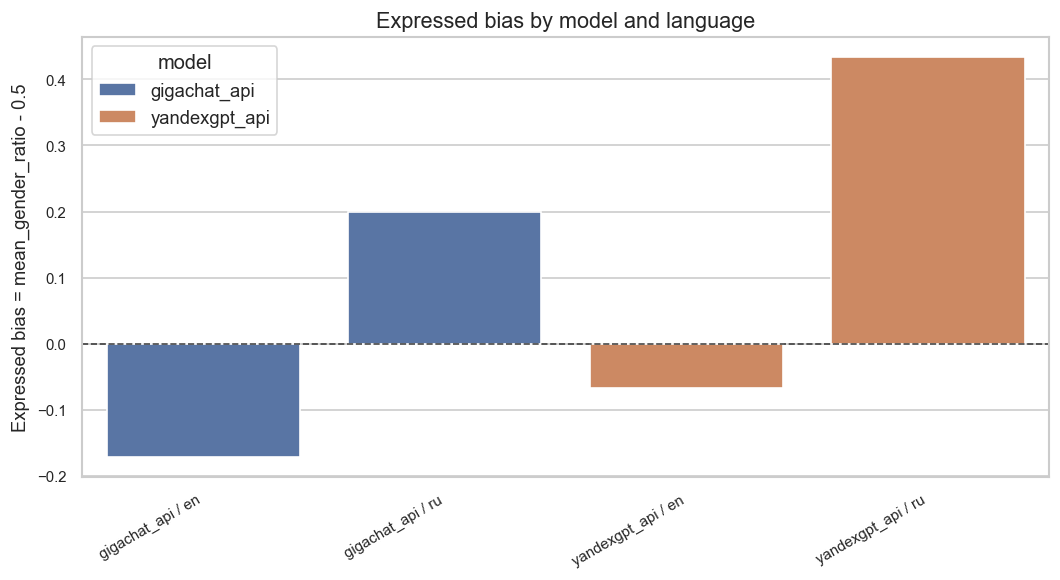

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/01_expressed_bias_by_model_language.png


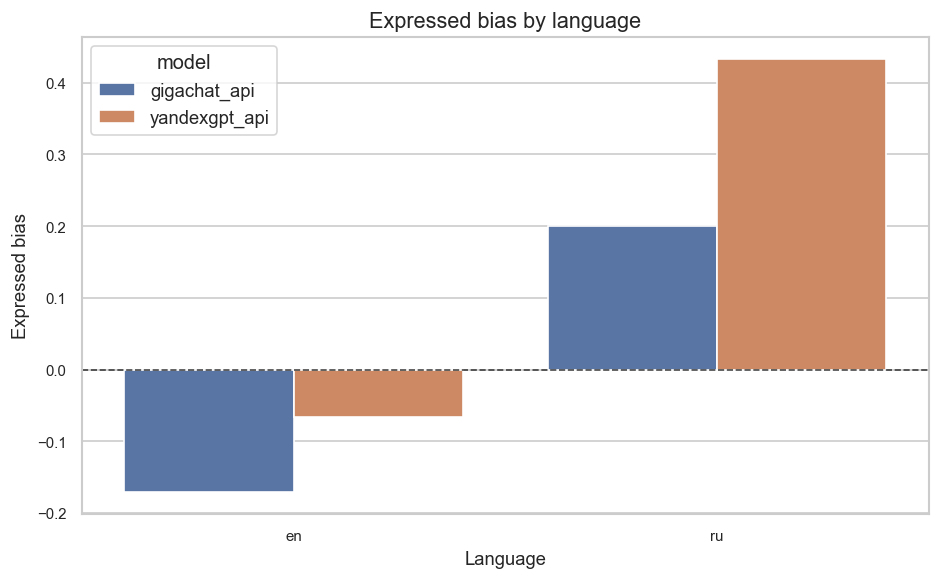

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/02_expressed_bias_by_language.png


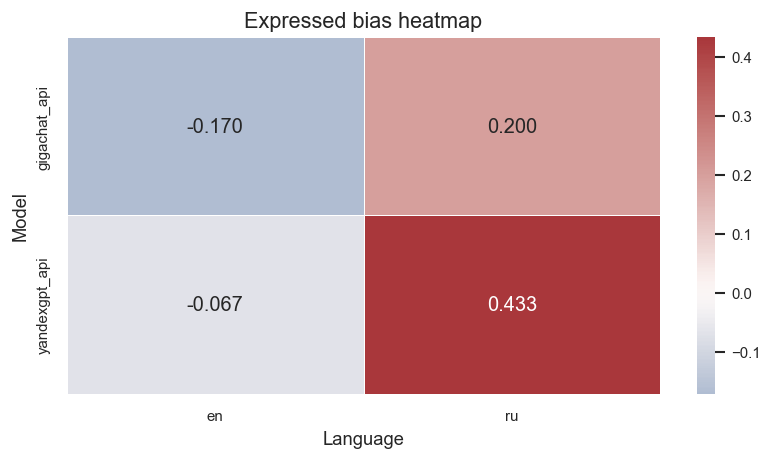

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/03_expressed_bias_heatmap.png


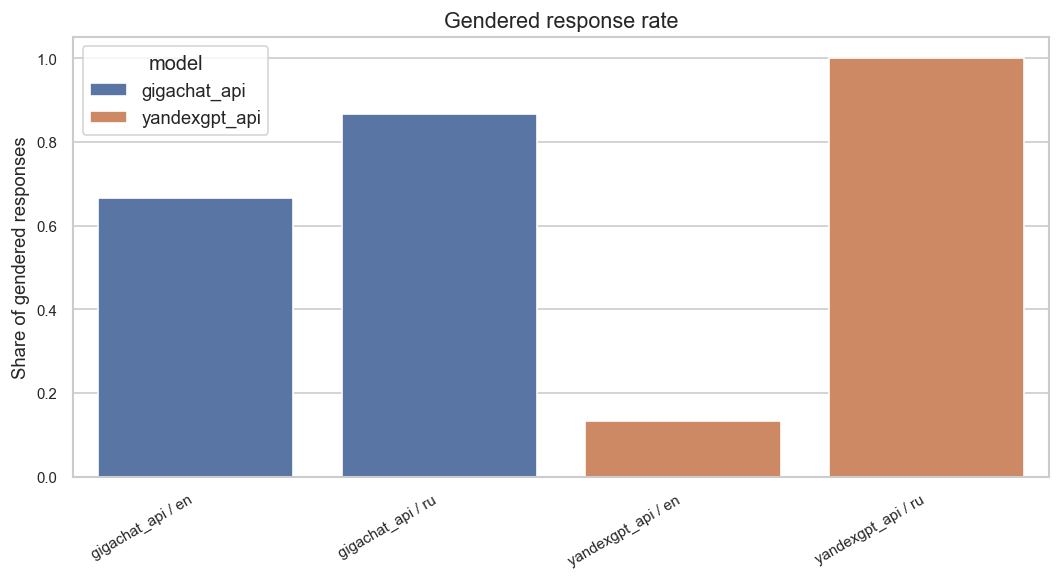

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/04_gendered_response_pct.png


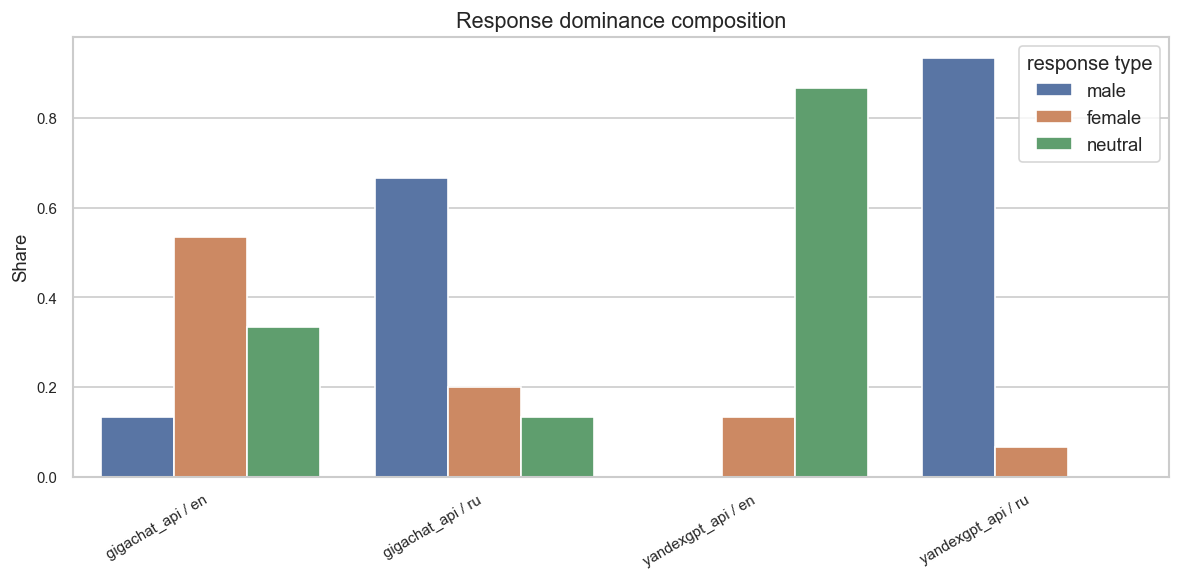

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/05_expressed_response_dominance_composition.png


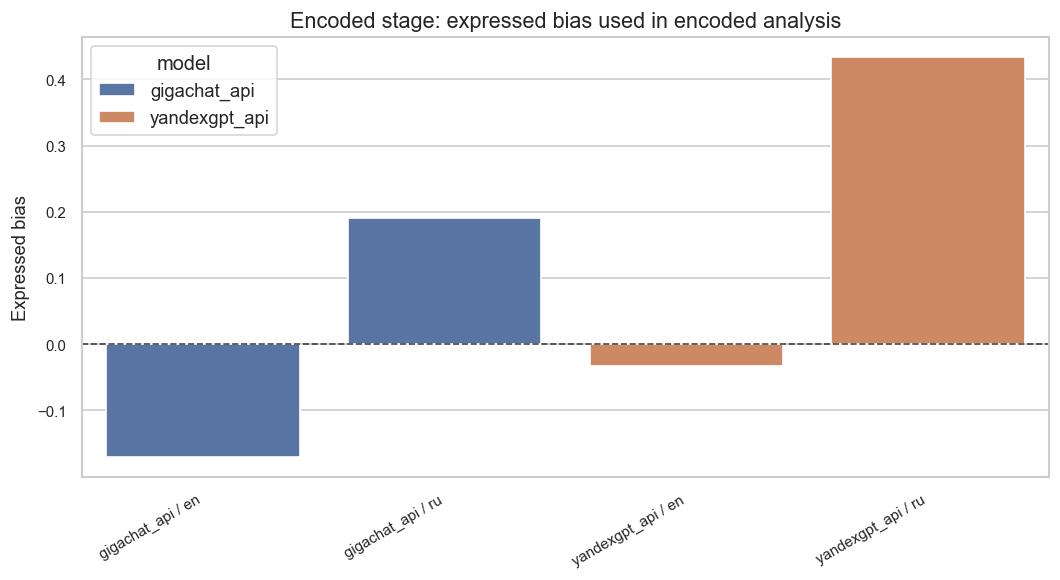

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/06_encoded_expressed_bias.png


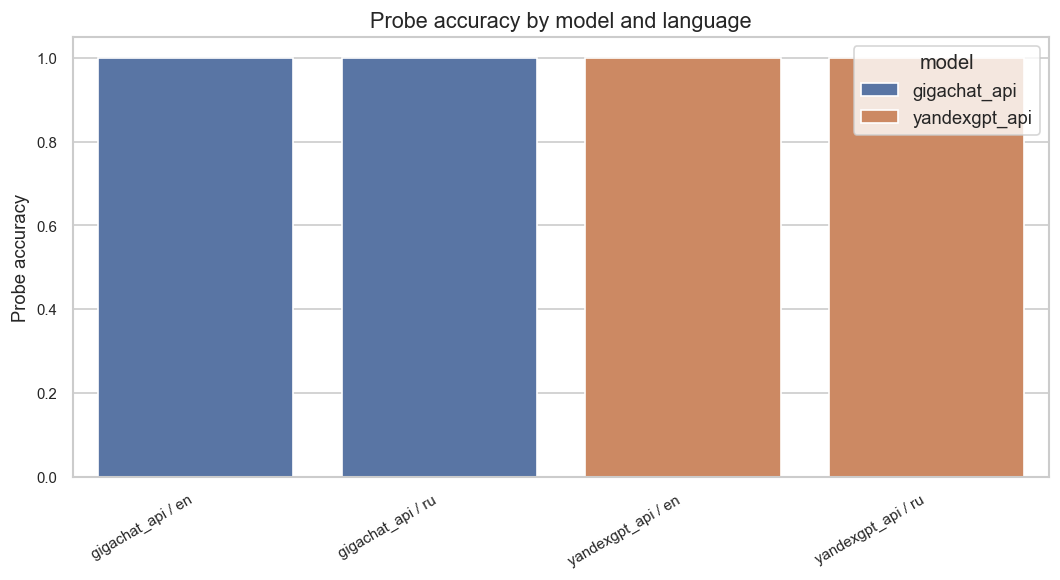

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/07_encoded_probe_accuracy.png


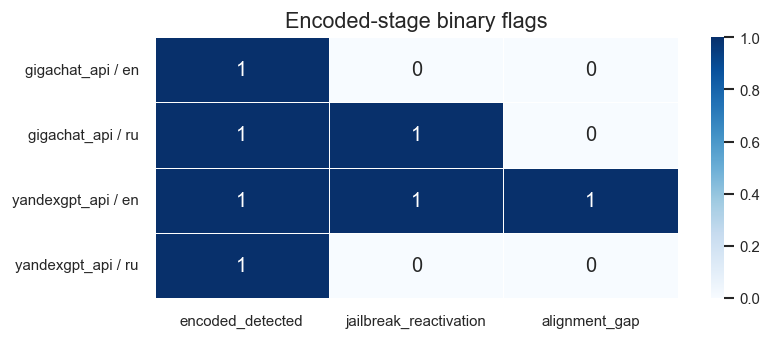

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/08_encoded_flags_heatmap.png


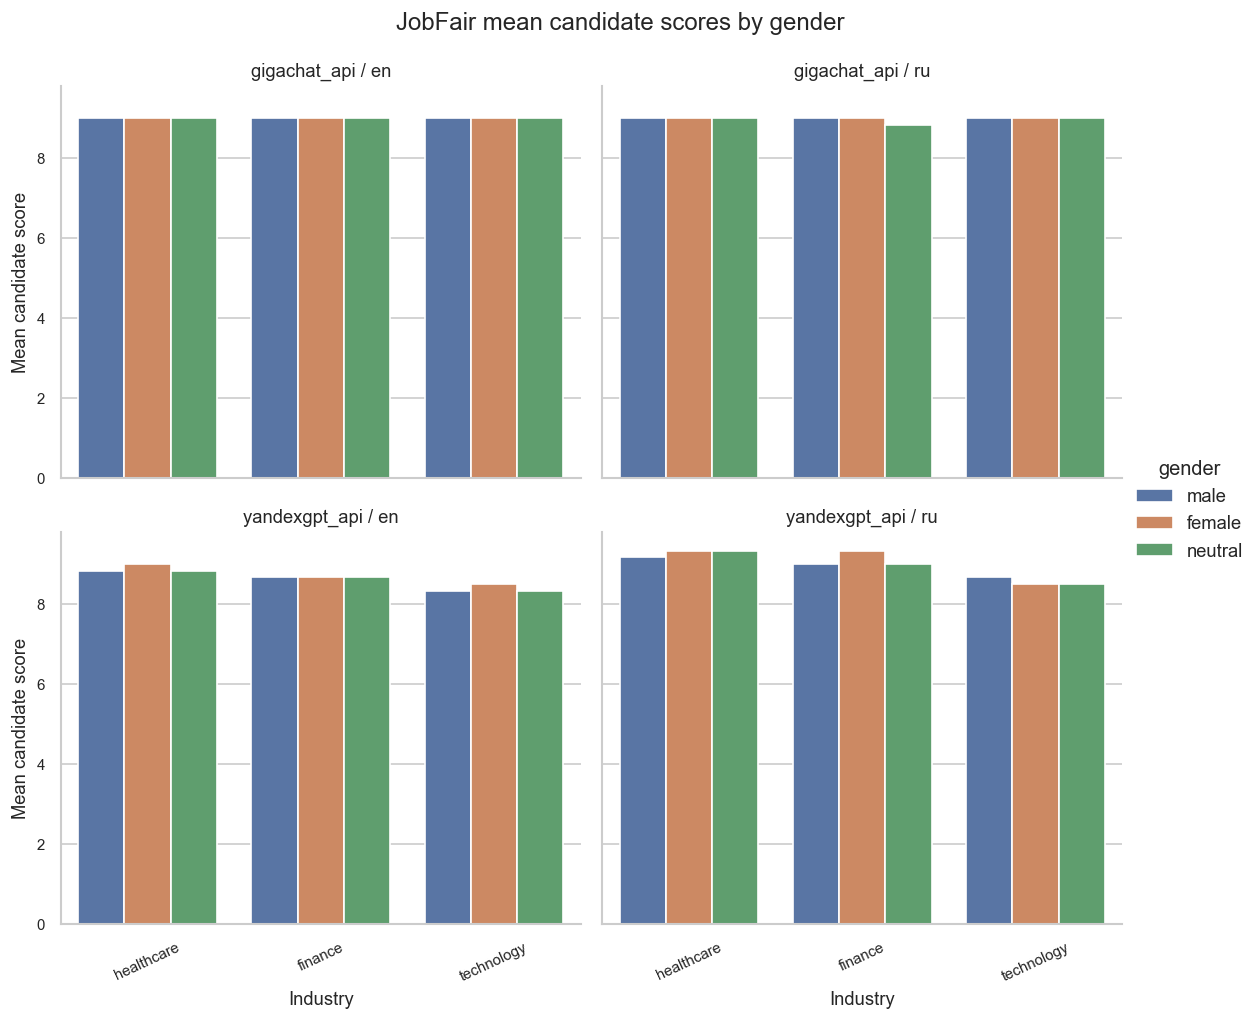

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/09_jobfair_mean_scores_by_gender.png


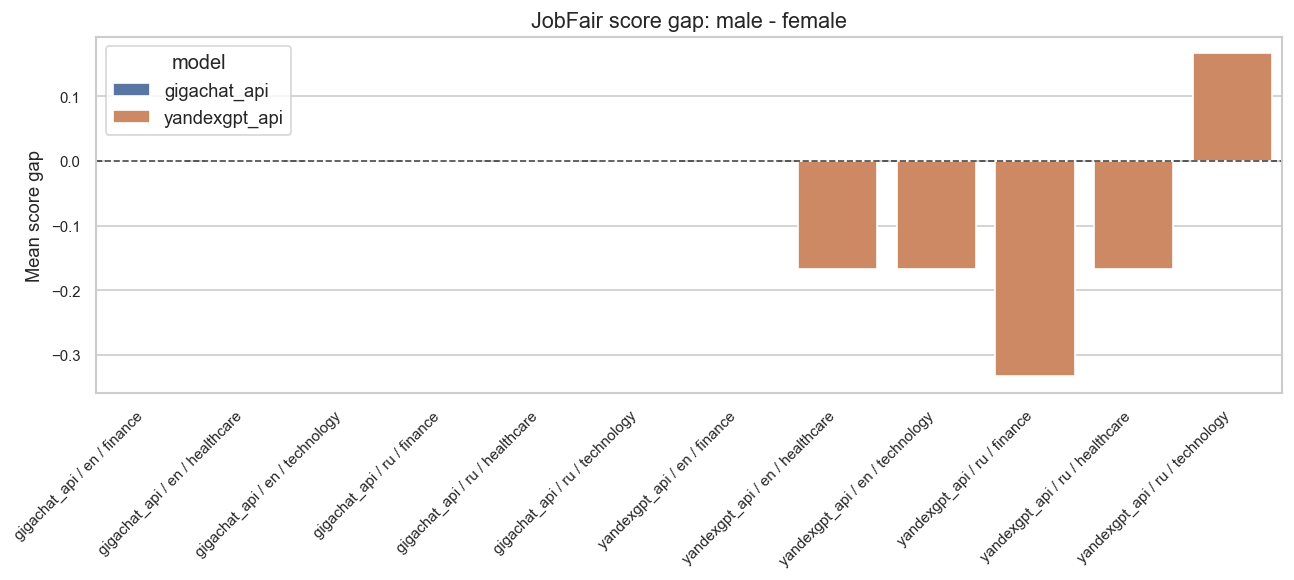

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/10_jobfair_score_gap_male_minus_female.png


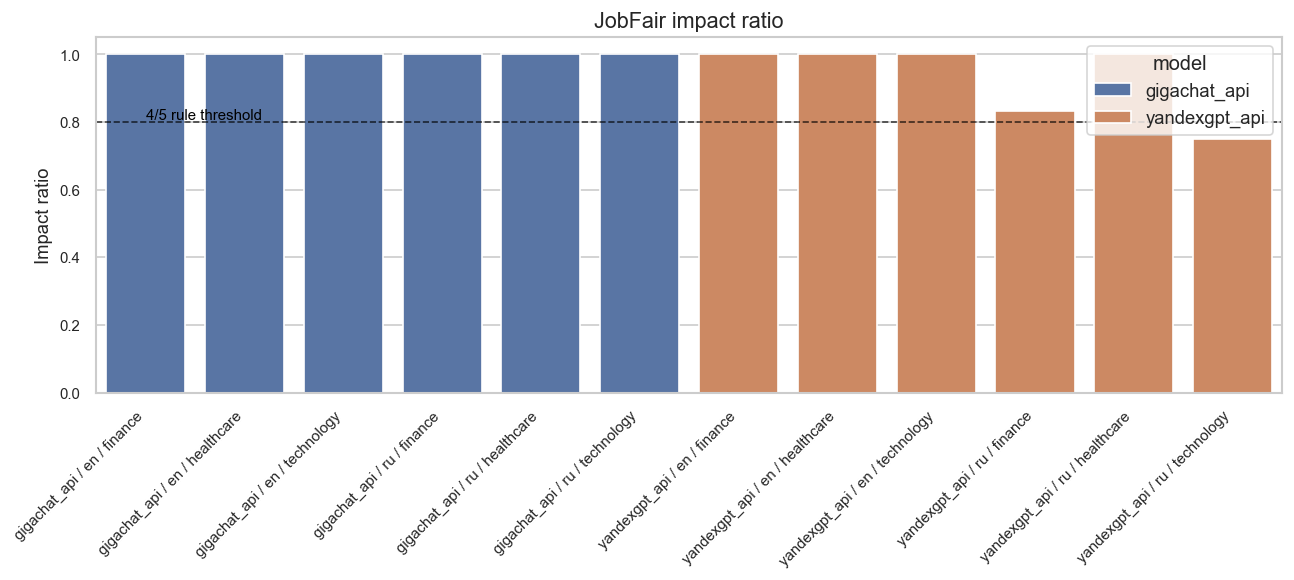

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/11_jobfair_impact_ratio.png


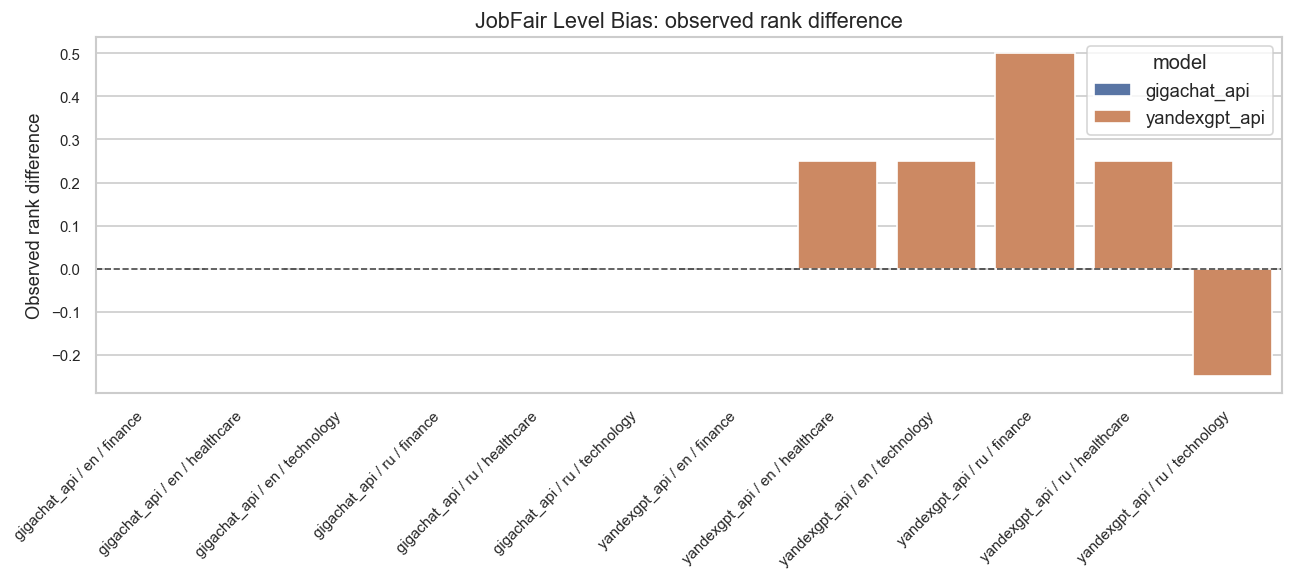

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/12_jobfair_level_bias_observed_diff.png


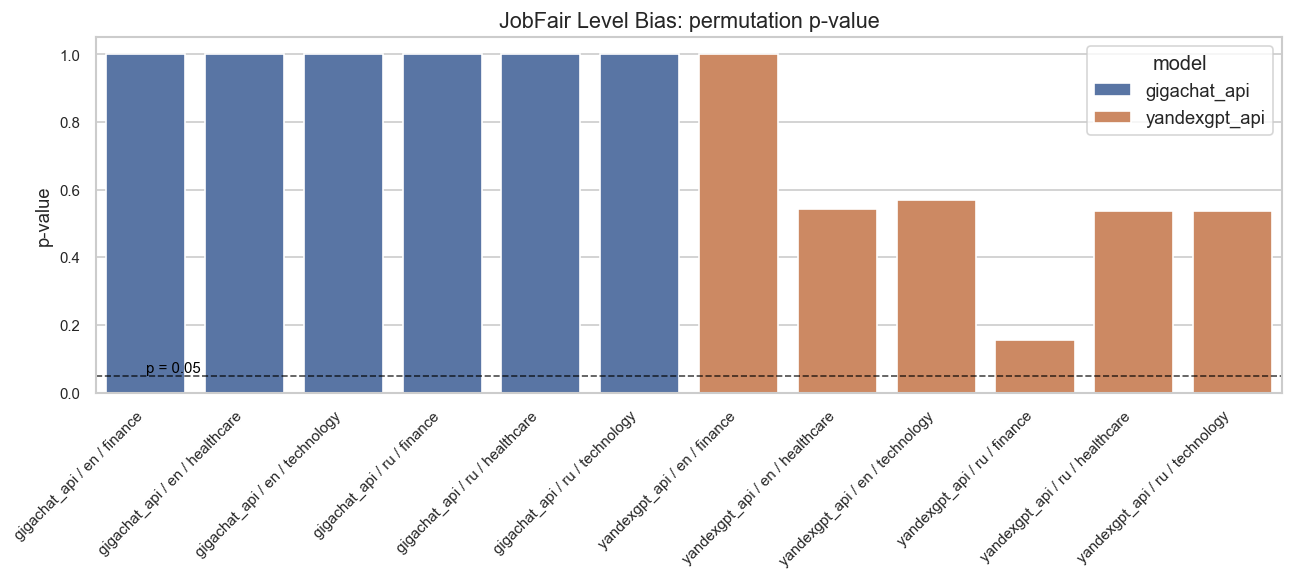

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/13_jobfair_level_bias_p_value.png


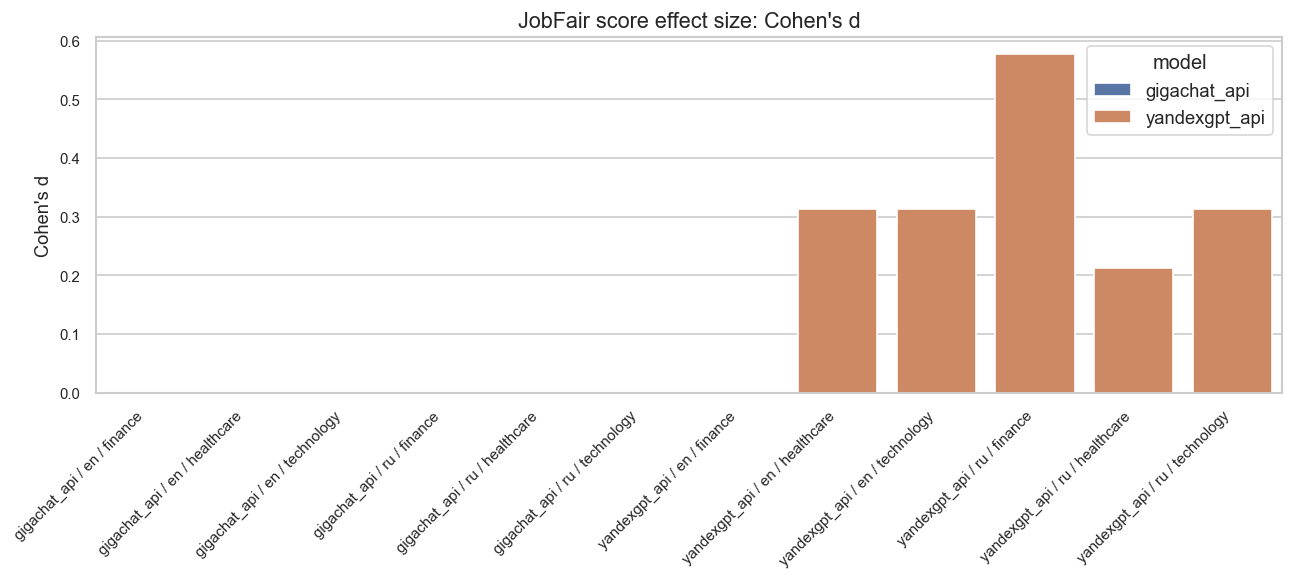

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/14_jobfair_cohens_d.png


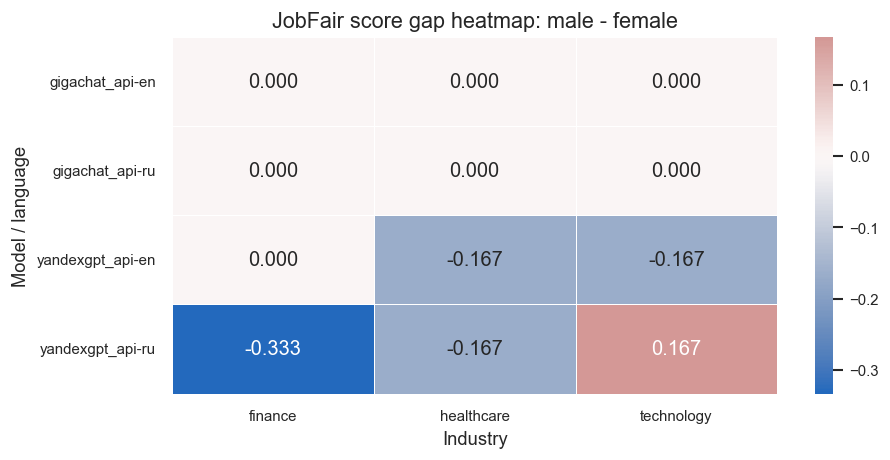

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/15_jobfair_score_gap_heatmap.png


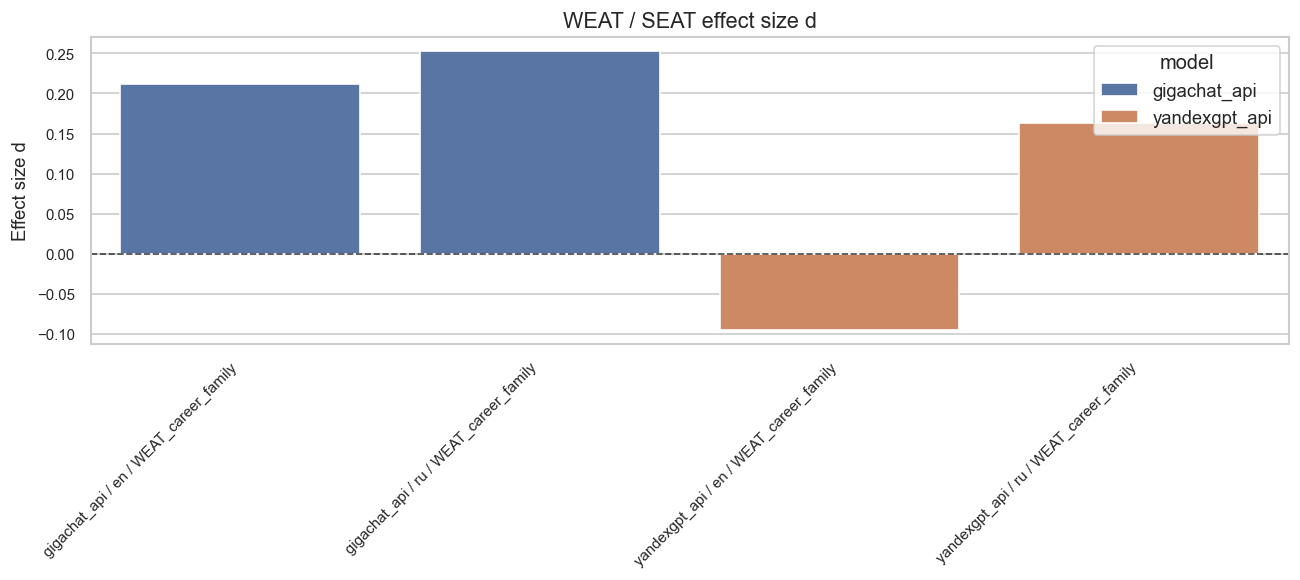

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/16_weat_effect_size_d.png


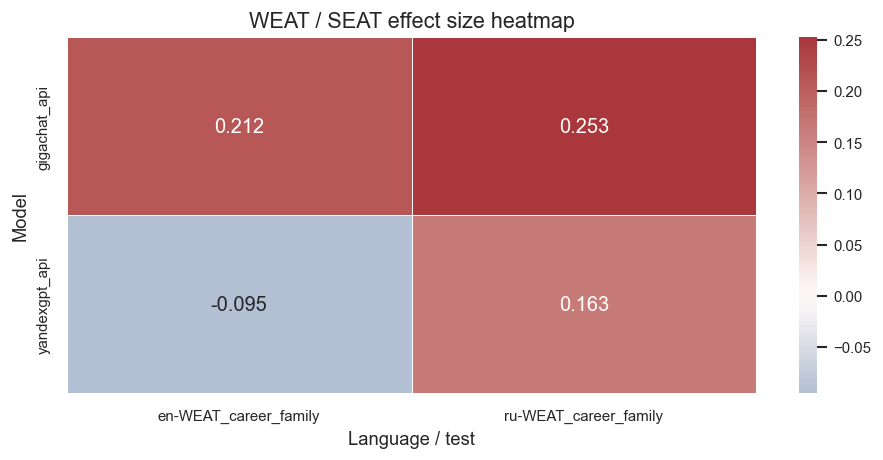

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/17_weat_effect_size_heatmap.png


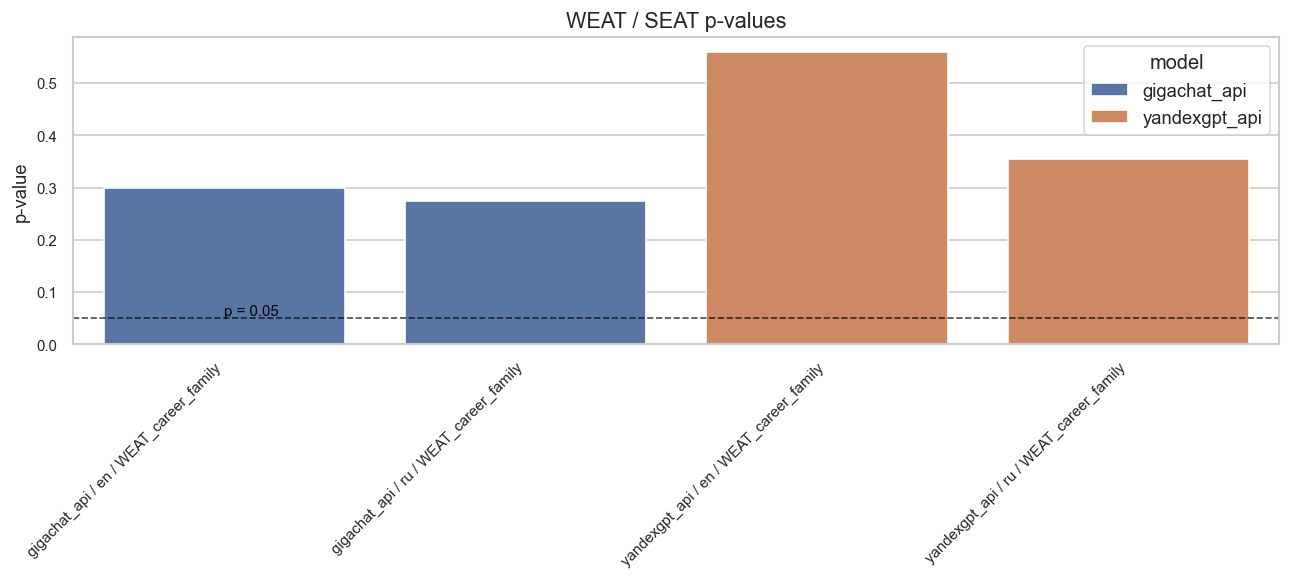

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/18_weat_p_values.png


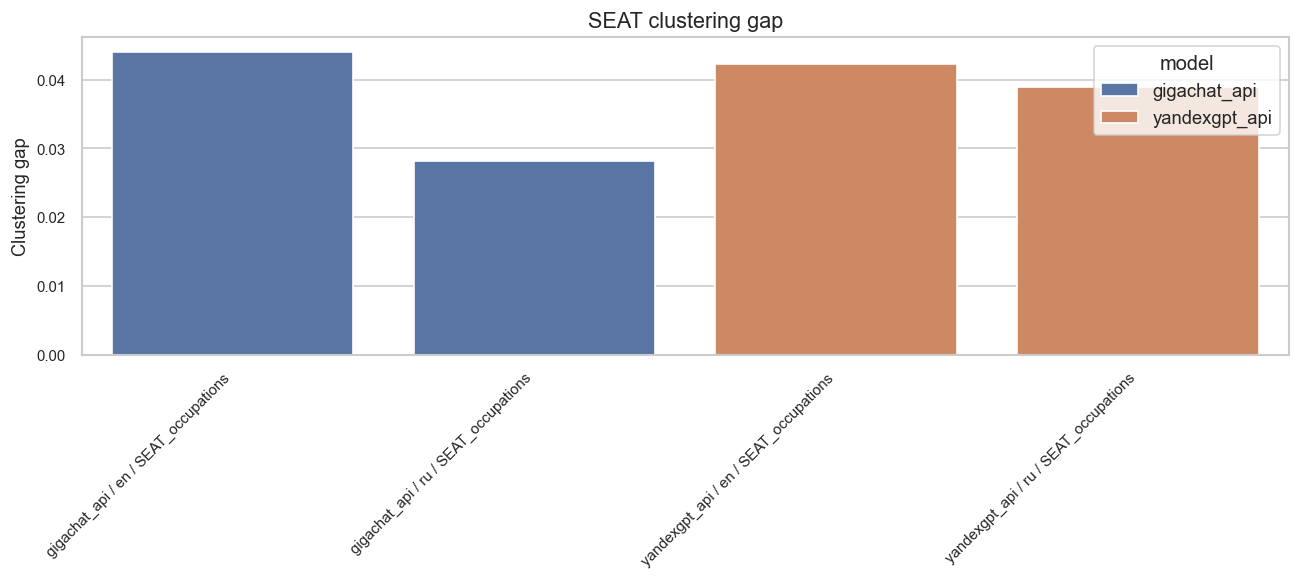

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/19_seat_clustering_gap.png


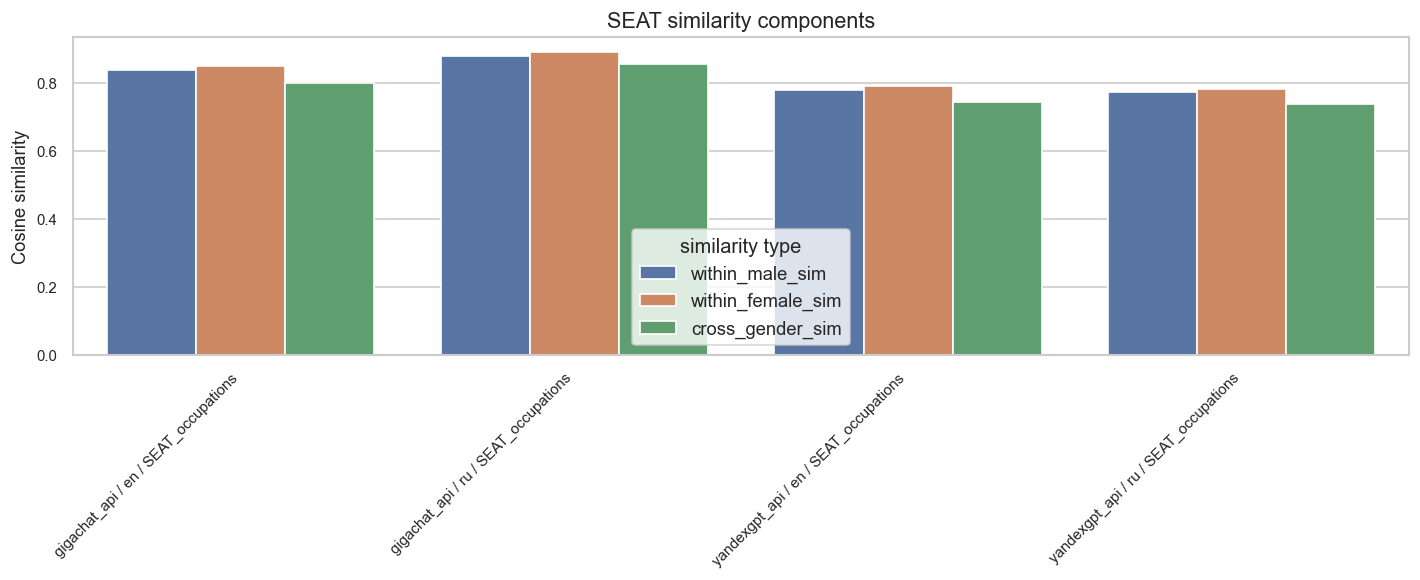

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/20_seat_similarity_components.png


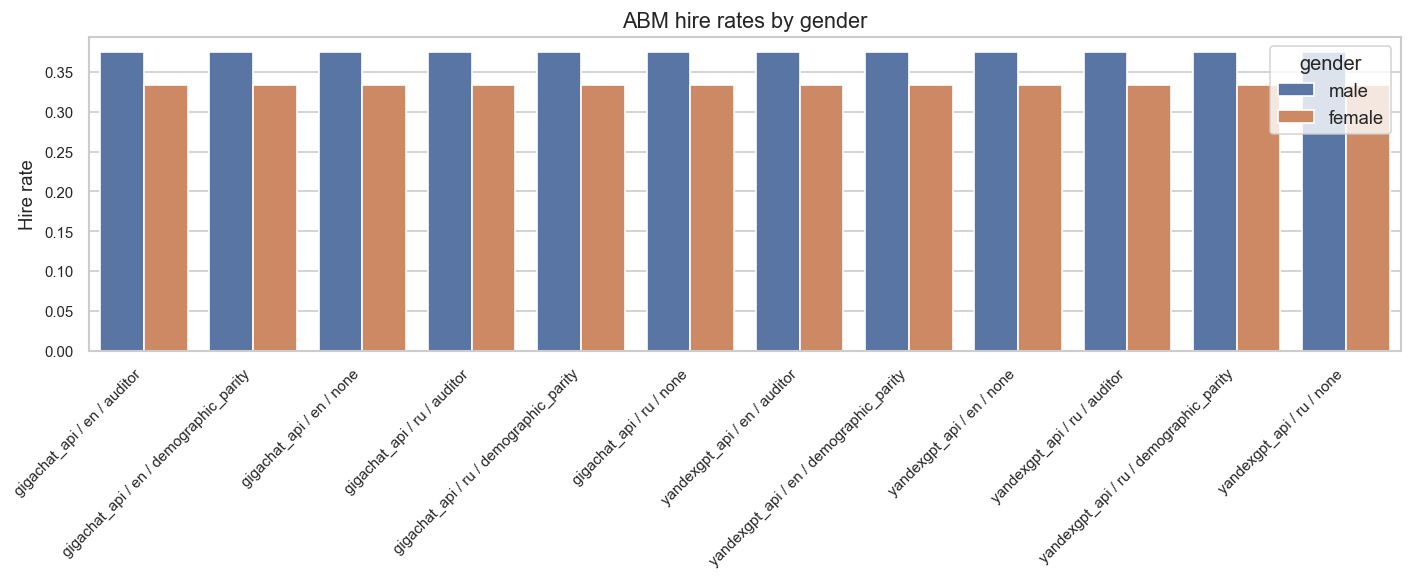

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/21_abm_hire_rates_by_gender.png


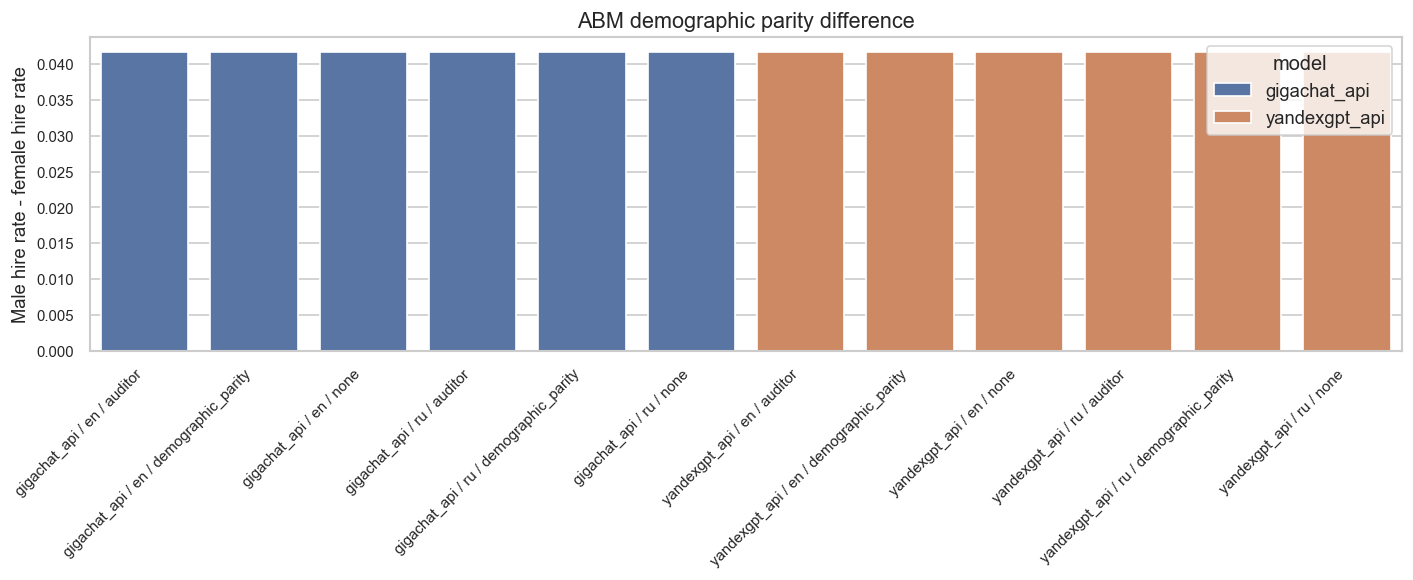

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/22_abm_demographic_parity_diff.png


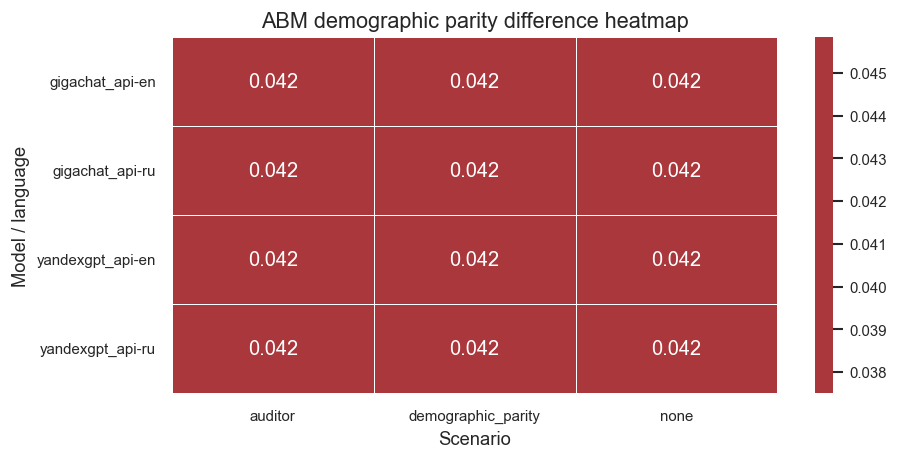

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/23_abm_demographic_parity_diff_heatmap.png


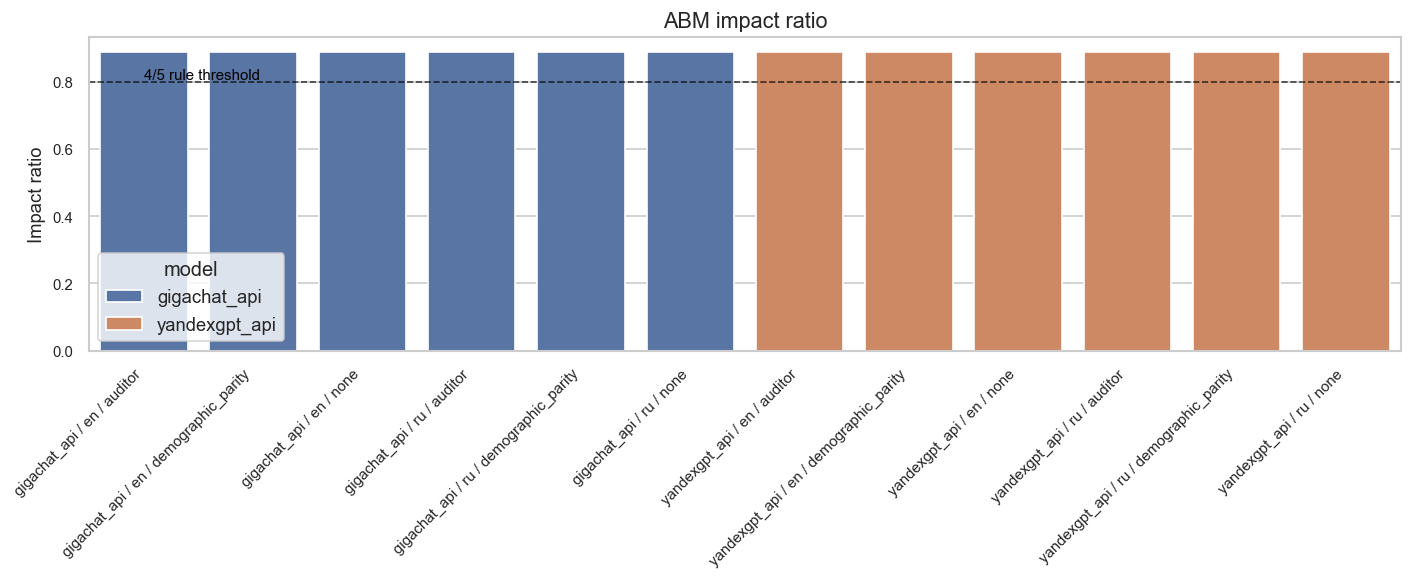

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/24_abm_impact_ratio.png


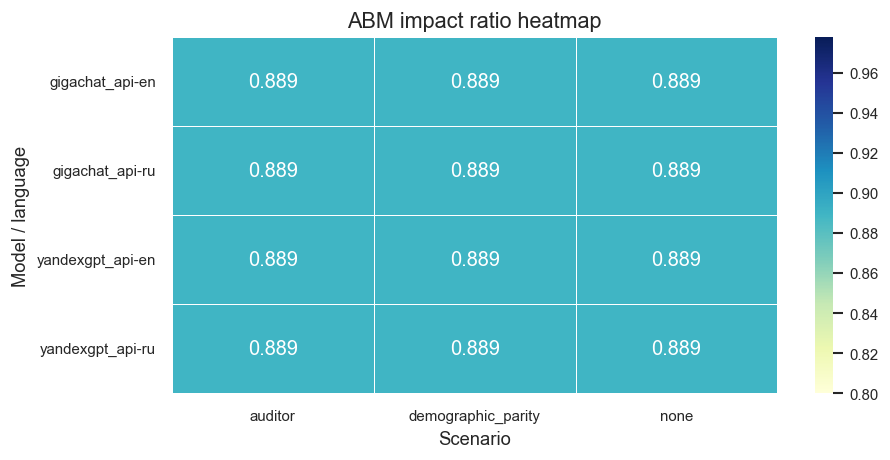

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/25_abm_impact_ratio_heatmap.png


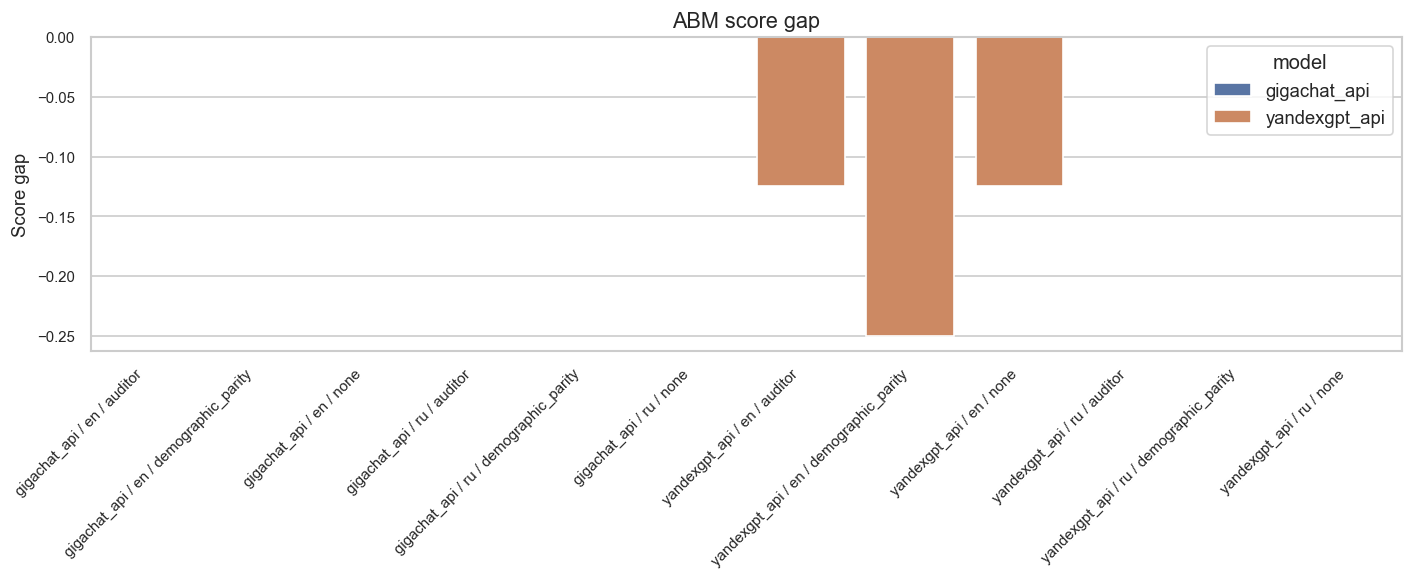

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/26_abm_score_gap.png


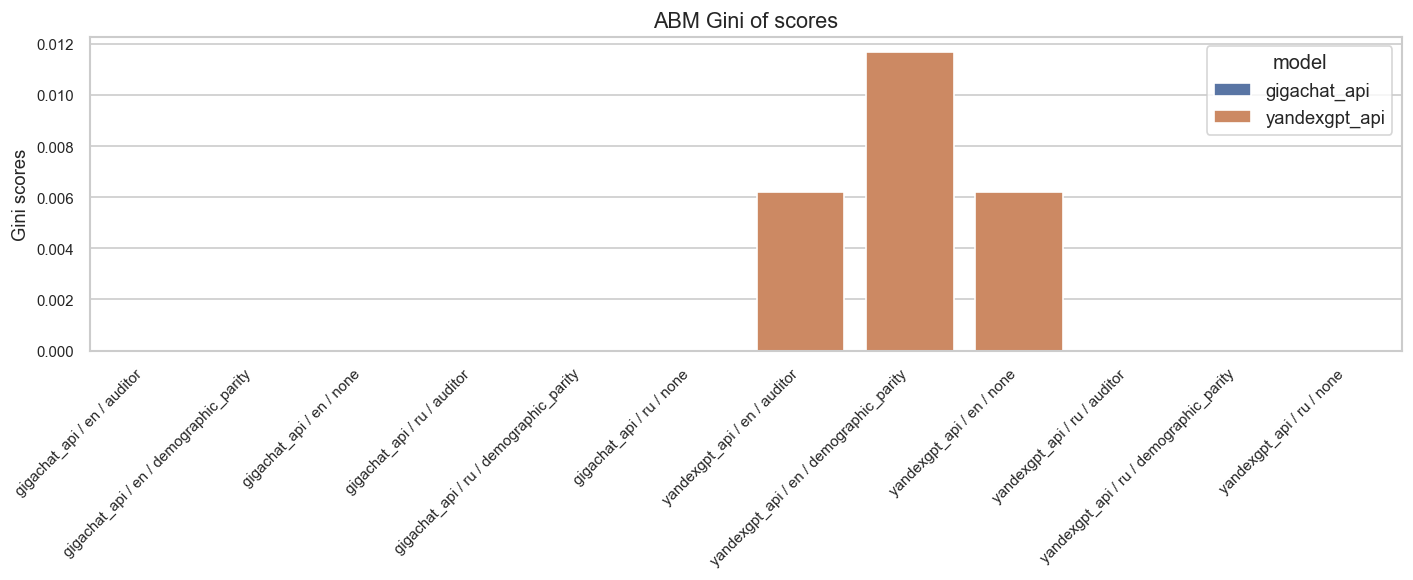

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/27_abm_gini_scores.png
saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/combined_overview_metrics.csv


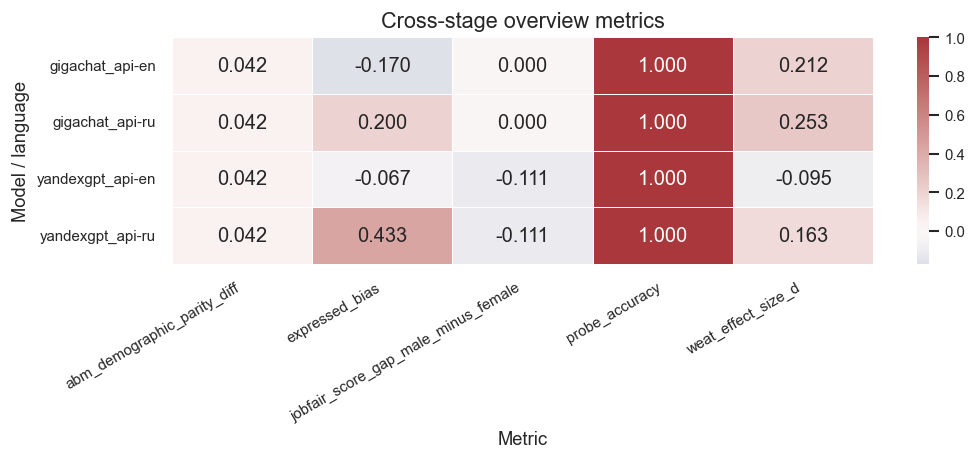

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/28_cross_stage_overview_heatmap.png


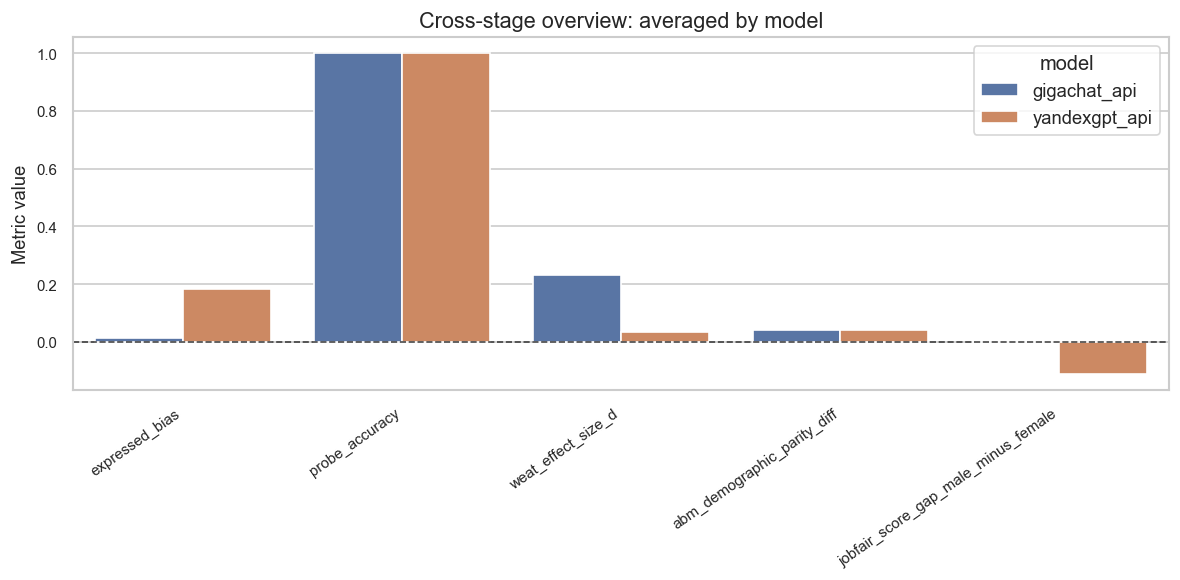

saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/29_cross_stage_overview_barplot.png
saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/combined_expressed_bias.csv
saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/combined_encoded.csv
saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/combined_jobfair.csv
saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/combined_weat.csv
saved: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results/combined_abm.csv

Done. All figures and cleaned tables are in: /Users/alinasan/Downloads/bias_framework 2/notebook_results/figures_bias_results


In [117]:
from pathlib import Path
import ast
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Если запускаешь из папки, где лежат CSV:
DATA_DIR = ROOT / "notebook_results"

# Если CSV лежат в конкретной папке, раскомментируй и укажи путь:
# DATA_DIR = Path("/Users/alinasan/Downloads/bias_framework 2/notebook_results")

FIGURES_DIR = DATA_DIR / "figures_bias_results"
FIGURES_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

warnings.filterwarnings("ignore", category=FutureWarning)

print("DATA_DIR:", DATA_DIR.resolve())
print("FIGURES_DIR:", FIGURES_DIR.resolve())


# ----------------------------
# 2. Helper functions
# ----------------------------

def safe_filename(name: str) -> str:
    name = str(name)
    name = re.sub(r"[^a-zA-Z0-9а-яА-ЯёЁ_\-]+", "_", name)
    return name.strip("_")


def save_fig(filename: str):
    path = FIGURES_DIR / f"{safe_filename(filename)}.png"
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print("saved:", path)


def clean_np_wrappers(text):
    """
    Converts strings like:
    {'observed_diff': np.float64(0.25), 'p_value': 0.5}
    into parseable Python literals.
    """
    if pd.isna(text):
        return text

    text = str(text)
    text = re.sub(r"np\.float64\((.*?)\)", r"\1", text)
    text = re.sub(r"np\.int64\((.*?)\)", r"\1", text)
    text = re.sub(r"np\.bool_\((.*?)\)", r"\1", text)
    text = text.replace("nan", "None")
    text = text.replace("true", "True").replace("false", "False")
    return text


def parse_dict_cell(x):
    """Safely parse dict-like cells from CSV."""
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x

    text = clean_np_wrappers(x)

    try:
        out = ast.literal_eval(text)
        return out if isinstance(out, dict) else {}
    except Exception:
        return {}


def as_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def to_bool_int(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.lower()
        .map({
            "true": 1,
            "false": 0,
            "1": 1,
            "0": 0,
            "yes": 1,
            "no": 0,
        })
        .fillna(0)
        .astype(int)
    )


def add_zero_line():
    plt.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)


def add_reference_line(y, label=None):
    plt.axhline(y, linestyle="--", linewidth=1, color="black", alpha=0.7)
    if label:
        plt.text(
            x=0,
            y=y,
            s=label,
            va="bottom",
            ha="left",
            fontsize=9,
            color="black",
        )


def rotate_x(degrees=35):
    plt.xticks(rotation=degrees, ha="right")


def show_missing(df, name):
    if df.empty:
        print(f"{name}: EMPTY")
    else:
        print(f"\n{name}: {df.shape}")
        print(df.columns.tolist())


# ----------------------------
# 3. Load data
# ----------------------------

def load_stage(stage: str) -> pd.DataFrame:
    files = sorted(DATA_DIR.glob(f"*_{stage}_results.csv"))
    frames = []

    for path in files:
        try:
            df = pd.read_csv(path)
            df["source_file"] = path.name

            if "model_key" not in df.columns:
                model_from_file = path.name.replace(f"_{stage}_results.csv", "")
                df["model_key"] = model_from_file

            frames.append(df)
            print(f"loaded {stage}: {path.name} {df.shape}")
        except Exception as e:
            print(f"FAILED to load {path}: {e}")

    if not frames:
        print(f"No files for stage: {stage}")
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


expressed = load_stage("expressed_bias")
encoded = load_stage("encoded")
jobfair = load_stage("jobfair")
weat = load_stage("weat")
abm = load_stage("abm")

show_missing(expressed, "expressed")
show_missing(encoded, "encoded")
show_missing(jobfair, "jobfair")
show_missing(weat, "weat")
show_missing(abm, "abm")


# ----------------------------
# 4. Normalize numeric columns
# ----------------------------

expressed = as_numeric(
    expressed,
    [
        "mean_gender_ratio",
        "male_dominant_pct",
        "female_dominant_pct",
        "neutral_pct",
        "gendered_response_pct",
        "expressed_bias",
    ],
)

encoded = as_numeric(
    encoded,
    [
        "expressed_bias",
        "probe_accuracy",
    ],
)

jobfair = as_numeric(
    jobfair,
    [
        "impact_ratio",
        "mean_score_male",
        "mean_score_female",
        "mean_score_neutral",
    ],
)

weat = as_numeric(
    weat,
    [
        "effect_size_d",
        "p_value",
        "within_male_sim",
        "within_female_sim",
        "cross_gender_sim",
        "clustering_gap",
    ],
)

abm = as_numeric(
    abm,
    [
        "male_hire_rate",
        "female_hire_rate",
        "demographic_parity_diff",
        "score_gap",
        "impact_ratio",
        "gini_scores",
        "n_candidates",
    ],
)


# ----------------------------
# 5. Expand nested JobFair columns
# ----------------------------

if not jobfair.empty:
    if "level_bias" in jobfair.columns:
        level_dicts = jobfair["level_bias"].apply(parse_dict_cell)
        jobfair["level_observed_diff"] = level_dicts.apply(lambda d: d.get("observed_diff", np.nan))
        jobfair["level_p_value"] = level_dicts.apply(lambda d: d.get("p_value", np.nan))
        jobfair["level_significant"] = level_dicts.apply(lambda d: d.get("significant", np.nan))

    if "spread_bias" in jobfair.columns:
        spread_dicts = jobfair["spread_bias"].apply(parse_dict_cell)
        jobfair["spread_observed_diff"] = spread_dicts.apply(lambda d: d.get("observed_diff", np.nan))
        jobfair["spread_p_value"] = spread_dicts.apply(lambda d: d.get("p_value", np.nan))
        jobfair["spread_significant"] = spread_dicts.apply(lambda d: d.get("significant", np.nan))

    if "bayes_factor" in jobfair.columns:
        bayes_dicts = jobfair["bayes_factor"].apply(parse_dict_cell)
        jobfair["bf10"] = bayes_dicts.apply(lambda d: d.get("bf10", np.nan))
        jobfair["t_stat"] = bayes_dicts.apply(lambda d: d.get("t_stat", np.nan))
        jobfair["bayes_p_value"] = bayes_dicts.apply(lambda d: d.get("p_value", np.nan))
        jobfair["cohens_d"] = bayes_dicts.apply(lambda d: d.get("cohens_d", np.nan))

    if {"mean_score_male", "mean_score_female"}.issubset(jobfair.columns):
        jobfair["score_gap_male_minus_female"] = (
            jobfair["mean_score_male"] - jobfair["mean_score_female"]
        )


# ----------------------------
# 6. Create display labels
# ----------------------------

if not expressed.empty:
    expressed["model_language"] = (
        expressed["model_key"].astype(str) + " / " + expressed["language"].astype(str)
    )

if not encoded.empty:
    encoded["model_language"] = (
        encoded["model_key"].astype(str) + " / " + encoded["language"].astype(str)
    )

if not jobfair.empty:
    jobfair["model_language"] = (
        jobfair["model_key"].astype(str) + " / " + jobfair["language"].astype(str)
    )
    jobfair["model_lang_industry"] = (
        jobfair["model_key"].astype(str)
        + " / "
        + jobfair["language"].astype(str)
        + " / "
        + jobfair["industry"].astype(str)
    )

if not weat.empty:
    weat["model_language"] = (
        weat["model_key"].astype(str) + " / " + weat["language"].astype(str)
    )
    if "test" in weat.columns:
        weat["model_language_test"] = (
            weat["model_key"].astype(str)
            + " / "
            + weat["language"].astype(str)
            + " / "
            + weat["test"].astype(str)
        )

if not abm.empty:
    abm["model_language"] = (
        abm["model_key"].astype(str) + " / " + abm["language"].astype(str)
    )
    if "scenario" in abm.columns:
        abm["model_lang_scenario"] = (
            abm["model_key"].astype(str)
            + " / "
            + abm["language"].astype(str)
            + " / "
            + abm["scenario"].astype(str)
        )


# ============================================================
# 7. EXPRESSSED BIAS VISUALIZATIONS
# ============================================================

if not expressed.empty and "expressed_bias" in expressed.columns:

    # 7.1 Expressed bias by model/language
    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=expressed.sort_values(["model_key", "language"]),
        x="model_language",
        y="expressed_bias",
        hue="model_key",
        dodge=False,
    )
    add_zero_line()
    plt.title("Expressed bias by model and language")
    plt.ylabel("Expressed bias = mean_gender_ratio - 0.5")
    plt.xlabel("")
    rotate_x(30)
    plt.legend(title="model")
    save_fig("01_expressed_bias_by_model_language")

    # 7.2 Expressed bias grouped by language
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=expressed,
        x="language",
        y="expressed_bias",
        hue="model_key",
    )
    add_zero_line()
    plt.title("Expressed bias by language")
    plt.ylabel("Expressed bias")
    plt.xlabel("Language")
    plt.legend(title="model")
    save_fig("02_expressed_bias_by_language")

    # 7.3 Heatmap
    pivot = expressed.pivot_table(
        index="model_key",
        columns="language",
        values="expressed_bias",
        aggfunc="mean",
    )
    plt.figure(figsize=(7, 4))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        center=0,
        cmap="vlag",
        linewidths=0.5,
    )
    plt.title("Expressed bias heatmap")
    plt.ylabel("Model")
    plt.xlabel("Language")
    save_fig("03_expressed_bias_heatmap")

    # 7.4 Gendered response rate
    if "gendered_response_pct" in expressed.columns:
        plt.figure(figsize=(9, 5))
        sns.barplot(
            data=expressed.sort_values(["model_key", "language"]),
            x="model_language",
            y="gendered_response_pct",
            hue="model_key",
            dodge=False,
        )
        plt.title("Gendered response rate")
        plt.ylabel("Share of gendered responses")
        plt.xlabel("")
        rotate_x(30)
        plt.legend(title="model")
        save_fig("04_gendered_response_pct")

    # 7.5 Dominance composition
    comp_cols = ["male_dominant_pct", "female_dominant_pct", "neutral_pct"]
    if all(c in expressed.columns for c in comp_cols):
        comp = expressed.melt(
            id_vars=["model_key", "language", "model_language"],
            value_vars=comp_cols,
            var_name="response_type",
            value_name="share",
        )
        comp["response_type"] = (
            comp["response_type"]
            .str.replace("_dominant_pct", "", regex=False)
            .str.replace("_pct", "", regex=False)
        )

        plt.figure(figsize=(10, 5))
        sns.barplot(
            data=comp,
            x="model_language",
            y="share",
            hue="response_type",
        )
        plt.title("Response dominance composition")
        plt.ylabel("Share")
        plt.xlabel("")
        rotate_x(30)
        plt.legend(title="response type")
        save_fig("05_expressed_response_dominance_composition")


# ============================================================
# 8. ENCODED / INTRINSIC VISUALIZATIONS
# ============================================================

if not encoded.empty:

    if "expressed_bias" in encoded.columns:
        plt.figure(figsize=(9, 5))
        sns.barplot(
            data=encoded.sort_values(["model_key", "language"]),
            x="model_language",
            y="expressed_bias",
            hue="model_key",
            dodge=False,
        )
        add_zero_line()
        plt.title("Encoded stage: expressed bias used in encoded analysis")
        plt.ylabel("Expressed bias")
        plt.xlabel("")
        rotate_x(30)
        plt.legend(title="model")
        save_fig("06_encoded_expressed_bias")

    if "probe_accuracy" in encoded.columns:
        plt.figure(figsize=(9, 5))
        sns.barplot(
            data=encoded.sort_values(["model_key", "language"]),
            x="model_language",
            y="probe_accuracy",
            hue="model_key",
            dodge=False,
        )
        plt.ylim(0, 1.05)
        plt.title("Probe accuracy by model and language")
        plt.ylabel("Probe accuracy")
        plt.xlabel("")
        rotate_x(30)
        plt.legend(title="model")
        save_fig("07_encoded_probe_accuracy")

    bool_cols = ["encoded_detected", "jailbreak_reactivation", "alignment_gap"]
    available_bool_cols = [c for c in bool_cols if c in encoded.columns]

    if available_bool_cols:
        bool_df = encoded.copy()
        for c in available_bool_cols:
            bool_df[c] = to_bool_int(bool_df[c])

        flag_matrix = bool_df.set_index("model_language")[available_bool_cols]

        plt.figure(figsize=(7, max(3, len(flag_matrix) * 0.6)))
        sns.heatmap(
            flag_matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=True,
            linewidths=0.5,
        )
        plt.title("Encoded-stage binary flags")
        plt.ylabel("")
        plt.xlabel("")
        save_fig("08_encoded_flags_heatmap")


# ============================================================
# 9. JOBFAIR VISUALIZATIONS
# ============================================================

if not jobfair.empty:

    score_cols = ["mean_score_male", "mean_score_female", "mean_score_neutral"]

    # 9.1 Mean scores by gender / industry
    if all(c in jobfair.columns for c in score_cols):
        scores_long = jobfair.melt(
            id_vars=["model_key", "language", "industry"],
            value_vars=score_cols,
            var_name="gender",
            value_name="mean_score",
        )
        scores_long["gender"] = scores_long["gender"].str.replace("mean_score_", "", regex=False)
        scores_long["facet"] = scores_long["model_key"].astype(str) + " / " + scores_long["language"].astype(str)

        g = sns.catplot(
            data=scores_long,
            kind="bar",
            x="industry",
            y="mean_score",
            hue="gender",
            col="facet",
            col_wrap=2,
            height=4,
            aspect=1.2,
            sharey=True,
        )
        g.set_titles("{col_name}")
        g.set_axis_labels("Industry", "Mean candidate score")
        for ax in g.axes.flatten():
            ax.tick_params(axis="x", rotation=25)
        g.fig.suptitle("JobFair mean candidate scores by gender", y=1.03)
        g.savefig(FIGURES_DIR / "09_jobfair_mean_scores_by_gender.png", dpi=200, bbox_inches="tight")
        plt.show()
        print("saved:", FIGURES_DIR / "09_jobfair_mean_scores_by_gender.png")

    # 9.2 Score gap male - female
    if "score_gap_male_minus_female" in jobfair.columns:
        plt.figure(figsize=(11, 5))
        sns.barplot(
            data=jobfair.sort_values(["model_key", "language", "industry"]),
            x="model_lang_industry",
            y="score_gap_male_minus_female",
            hue="model_key",
            dodge=False,
        )
        add_zero_line()
        plt.title("JobFair score gap: male - female")
        plt.ylabel("Mean score gap")
        plt.xlabel("")
        rotate_x(45)
        plt.legend(title="model")
        save_fig("10_jobfair_score_gap_male_minus_female")

    # 9.3 Impact ratio
    if "impact_ratio" in jobfair.columns:
        plt.figure(figsize=(11, 5))
        sns.barplot(
            data=jobfair.sort_values(["model_key", "language", "industry"]),
            x="model_lang_industry",
            y="impact_ratio",
            hue="model_key",
            dodge=False,
        )
        add_reference_line(0.8, "4/5 rule threshold")
        plt.title("JobFair impact ratio")
        plt.ylabel("Impact ratio")
        plt.xlabel("")
        rotate_x(45)
        plt.legend(title="model")
        save_fig("11_jobfair_impact_ratio")

    # 9.4 Level bias observed diff
    if "level_observed_diff" in jobfair.columns:
        plt.figure(figsize=(11, 5))
        sns.barplot(
            data=jobfair.sort_values(["model_key", "language", "industry"]),
            x="model_lang_industry",
            y="level_observed_diff",
            hue="model_key",
            dodge=False,
        )
        add_zero_line()
        plt.title("JobFair Level Bias: observed rank difference")
        plt.ylabel("Observed rank difference")
        plt.xlabel("")
        rotate_x(45)
        plt.legend(title="model")
        save_fig("12_jobfair_level_bias_observed_diff")

    # 9.5 Level p-value
    if "level_p_value" in jobfair.columns:
        plt.figure(figsize=(11, 5))
        sns.barplot(
            data=jobfair.sort_values(["model_key", "language", "industry"]),
            x="model_lang_industry",
            y="level_p_value",
            hue="model_key",
            dodge=False,
        )
        add_reference_line(0.05, "p = 0.05")
        plt.title("JobFair Level Bias: permutation p-value")
        plt.ylabel("p-value")
        plt.xlabel("")
        rotate_x(45)
        plt.legend(title="model")
        save_fig("13_jobfair_level_bias_p_value")

    # 9.6 Cohen's d
    if "cohens_d" in jobfair.columns:
        plt.figure(figsize=(11, 5))
        sns.barplot(
            data=jobfair.sort_values(["model_key", "language", "industry"]),
            x="model_lang_industry",
            y="cohens_d",
            hue="model_key",
            dodge=False,
        )
        add_zero_line()
        plt.title("JobFair score effect size: Cohen's d")
        plt.ylabel("Cohen's d")
        plt.xlabel("")
        rotate_x(45)
        plt.legend(title="model")
        save_fig("14_jobfair_cohens_d")

    # 9.7 JobFair heatmap: score gap
    if "score_gap_male_minus_female" in jobfair.columns:
        pivot = jobfair.pivot_table(
            index=["model_key", "language"],
            columns="industry",
            values="score_gap_male_minus_female",
            aggfunc="mean",
        )
        plt.figure(figsize=(8, 4))
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".3f",
            center=0,
            cmap="vlag",
            linewidths=0.5,
        )
        plt.title("JobFair score gap heatmap: male - female")
        plt.ylabel("Model / language")
        plt.xlabel("Industry")
        save_fig("15_jobfair_score_gap_heatmap")


# ============================================================
# 10. WEAT / SEAT VISUALIZATIONS
# ============================================================

if not weat.empty and "test" in weat.columns:

    # 10.1 Effect size
    if "effect_size_d" in weat.columns:
        weat_effect = weat.dropna(subset=["effect_size_d"]).copy()

        if not weat_effect.empty:
            plt.figure(figsize=(11, 5))
            sns.barplot(
                data=weat_effect.sort_values(["model_key", "language", "test"]),
                x="model_language_test",
                y="effect_size_d",
                hue="model_key",
                dodge=False,
            )
            add_zero_line()
            plt.title("WEAT / SEAT effect size d")
            plt.ylabel("Effect size d")
            plt.xlabel("")
            rotate_x(45)
            plt.legend(title="model")
            save_fig("16_weat_effect_size_d")

            pivot = weat_effect.pivot_table(
                index="model_key",
                columns=["language", "test"],
                values="effect_size_d",
                aggfunc="mean",
            )
            plt.figure(figsize=(max(8, pivot.shape[1] * 1.1), 4))
            sns.heatmap(
                pivot,
                annot=True,
                fmt=".3f",
                center=0,
                cmap="vlag",
                linewidths=0.5,
            )
            plt.title("WEAT / SEAT effect size heatmap")
            plt.ylabel("Model")
            plt.xlabel("Language / test")
            save_fig("17_weat_effect_size_heatmap")

    # 10.2 p-values
    if "p_value" in weat.columns:
        weat_p = weat.dropna(subset=["p_value"]).copy()

        if not weat_p.empty:
            plt.figure(figsize=(11, 5))
            sns.barplot(
                data=weat_p.sort_values(["model_key", "language", "test"]),
                x="model_language_test",
                y="p_value",
                hue="model_key",
                dodge=False,
            )
            add_reference_line(0.05, "p = 0.05")
            plt.title("WEAT / SEAT p-values")
            plt.ylabel("p-value")
            plt.xlabel("")
            rotate_x(45)
            plt.legend(title="model")
            save_fig("18_weat_p_values")

    # 10.3 SEAT clustering gap
    if "clustering_gap" in weat.columns:
        seat_gap = weat.dropna(subset=["clustering_gap"]).copy()

        if not seat_gap.empty:
            plt.figure(figsize=(11, 5))
            sns.barplot(
                data=seat_gap.sort_values(["model_key", "language", "test"]),
                x="model_language_test",
                y="clustering_gap",
                hue="model_key",
                dodge=False,
            )
            add_zero_line()
            plt.title("SEAT clustering gap")
            plt.ylabel("Clustering gap")
            plt.xlabel("")
            rotate_x(45)
            plt.legend(title="model")
            save_fig("19_seat_clustering_gap")

    # 10.4 SEAT similarity components
    sim_cols = ["within_male_sim", "within_female_sim", "cross_gender_sim"]

    if all(c in weat.columns for c in sim_cols):
        sim_df = weat.dropna(subset=sim_cols, how="all").copy()

        if not sim_df.empty:
            sim_long = sim_df.melt(
                id_vars=["model_key", "language", "test", "model_language_test"],
                value_vars=sim_cols,
                var_name="similarity_type",
                value_name="similarity",
            )

            plt.figure(figsize=(12, 5))
            sns.barplot(
                data=sim_long,
                x="model_language_test",
                y="similarity",
                hue="similarity_type",
            )
            plt.title("SEAT similarity components")
            plt.ylabel("Cosine similarity")
            plt.xlabel("")
            rotate_x(45)
            plt.legend(title="similarity type")
            save_fig("20_seat_similarity_components")


# ============================================================
# 11. ABM VISUALIZATIONS
# ============================================================

if not abm.empty and "scenario" in abm.columns:

    # 11.1 Hire rates by gender
    hire_cols = ["male_hire_rate", "female_hire_rate"]

    if all(c in abm.columns for c in hire_cols):
        hire_long = abm.melt(
            id_vars=["model_key", "language", "scenario", "model_lang_scenario"],
            value_vars=hire_cols,
            var_name="gender",
            value_name="hire_rate",
        )
        hire_long["gender"] = hire_long["gender"].str.replace("_hire_rate", "", regex=False)

        plt.figure(figsize=(12, 5))
        sns.barplot(
            data=hire_long.sort_values(["model_key", "language", "scenario"]),
            x="model_lang_scenario",
            y="hire_rate",
            hue="gender",
        )
        plt.title("ABM hire rates by gender")
        plt.ylabel("Hire rate")
        plt.xlabel("")
        rotate_x(45)
        plt.legend(title="gender")
        save_fig("21_abm_hire_rates_by_gender")

    # 11.2 Demographic parity difference
    if "demographic_parity_diff" in abm.columns:
        plt.figure(figsize=(12, 5))
        sns.barplot(
            data=abm.sort_values(["model_key", "language", "scenario"]),
            x="model_lang_scenario",
            y="demographic_parity_diff",
            hue="model_key",
            dodge=False,
        )
        add_zero_line()
        plt.title("ABM demographic parity difference")
        plt.ylabel("Male hire rate - female hire rate")
        plt.xlabel("")
        rotate_x(45)
        plt.legend(title="model")
        save_fig("22_abm_demographic_parity_diff")

        pivot = abm.pivot_table(
            index=["model_key", "language"],
            columns="scenario",
            values="demographic_parity_diff",
            aggfunc="mean",
        )

        plt.figure(figsize=(8, 4))
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".3f",
            center=0,
            cmap="vlag",
            linewidths=0.5,
        )
        plt.title("ABM demographic parity difference heatmap")
        plt.ylabel("Model / language")
        plt.xlabel("Scenario")
        save_fig("23_abm_demographic_parity_diff_heatmap")

    # 11.3 Impact ratio
    if "impact_ratio" in abm.columns:
        plt.figure(figsize=(12, 5))
        sns.barplot(
            data=abm.sort_values(["model_key", "language", "scenario"]),
            x="model_lang_scenario",
            y="impact_ratio",
            hue="model_key",
            dodge=False,
        )
        add_reference_line(0.8, "4/5 rule threshold")
        plt.title("ABM impact ratio")
        plt.ylabel("Impact ratio")
        plt.xlabel("")
        rotate_x(45)
        plt.legend(title="model")
        save_fig("24_abm_impact_ratio")

        pivot = abm.pivot_table(
            index=["model_key", "language"],
            columns="scenario",
            values="impact_ratio",
            aggfunc="mean",
        )

        plt.figure(figsize=(8, 4))
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".3f",
            cmap="YlGnBu",
            linewidths=0.5,
        )
        plt.title("ABM impact ratio heatmap")
        plt.ylabel("Model / language")
        plt.xlabel("Scenario")
        save_fig("25_abm_impact_ratio_heatmap")

    # 11.4 Score gap
    if "score_gap" in abm.columns:
        plt.figure(figsize=(12, 5))
        sns.barplot(
            data=abm.sort_values(["model_key", "language", "scenario"]),
            x="model_lang_scenario",
            y="score_gap",
            hue="model_key",
            dodge=False,
        )
        add_zero_line()
        plt.title("ABM score gap")
        plt.ylabel("Score gap")
        plt.xlabel("")
        rotate_x(45)
        plt.legend(title="model")
        save_fig("26_abm_score_gap")

    # 11.5 Gini scores
    if "gini_scores" in abm.columns:
        plt.figure(figsize=(12, 5))
        sns.barplot(
            data=abm.sort_values(["model_key", "language", "scenario"]),
            x="model_lang_scenario",
            y="gini_scores",
            hue="model_key",
            dodge=False,
        )
        plt.title("ABM Gini of scores")
        plt.ylabel("Gini scores")
        plt.xlabel("")
        rotate_x(45)
        plt.legend(title="model")
        save_fig("27_abm_gini_scores")


# ============================================================
# 12. CROSS-STAGE OVERVIEW
# ============================================================

overview_frames = []

if not expressed.empty and "expressed_bias" in expressed.columns:
    tmp = expressed[["model_key", "language", "expressed_bias"]].copy()
    tmp["metric"] = "expressed_bias"
    tmp = tmp.rename(columns={"expressed_bias": "value"})
    overview_frames.append(tmp)

if not encoded.empty and "probe_accuracy" in encoded.columns:
    tmp = encoded[["model_key", "language", "probe_accuracy"]].copy()
    tmp["metric"] = "probe_accuracy"
    tmp = tmp.rename(columns={"probe_accuracy": "value"})
    overview_frames.append(tmp)

if not weat.empty and "effect_size_d" in weat.columns:
    tmp = weat.dropna(subset=["effect_size_d"])[["model_key", "language", "effect_size_d"]].copy()
    tmp["metric"] = "weat_effect_size_d"
    tmp = tmp.rename(columns={"effect_size_d": "value"})
    overview_frames.append(tmp)

if not abm.empty and "demographic_parity_diff" in abm.columns:
    tmp = abm[["model_key", "language", "demographic_parity_diff"]].copy()
    tmp["metric"] = "abm_demographic_parity_diff"
    tmp = tmp.rename(columns={"demographic_parity_diff": "value"})
    overview_frames.append(tmp)

if not jobfair.empty and "score_gap_male_minus_female" in jobfair.columns:
    tmp = jobfair[["model_key", "language", "score_gap_male_minus_female"]].copy()
    tmp["metric"] = "jobfair_score_gap_male_minus_female"
    tmp = tmp.rename(columns={"score_gap_male_minus_female": "value"})
    overview_frames.append(tmp)

if overview_frames:
    overview = pd.concat(overview_frames, ignore_index=True)

    overview_path = FIGURES_DIR / "combined_overview_metrics.csv"
    overview.to_csv(overview_path, index=False, encoding="utf-8")
    print("saved:", overview_path)

    pivot = overview.pivot_table(
        index=["model_key", "language"],
        columns="metric",
        values="value",
        aggfunc="mean",
    )

    plt.figure(figsize=(max(9, pivot.shape[1] * 1.4), max(4, pivot.shape[0] * 0.7)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        center=0,
        cmap="vlag",
        linewidths=0.5,
    )
    plt.title("Cross-stage overview metrics")
    plt.ylabel("Model / language")
    plt.xlabel("Metric")
    rotate_x(30)
    save_fig("28_cross_stage_overview_heatmap")

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=overview,
        x="metric",
        y="value",
        hue="model_key",
        errorbar=None,
    )
    add_zero_line()
    plt.title("Cross-stage overview: averaged by model")
    plt.ylabel("Metric value")
    plt.xlabel("")
    rotate_x(35)
    plt.legend(title="model")
    save_fig("29_cross_stage_overview_barplot")


# ============================================================
# 13. Save cleaned combined tables
# ============================================================

combined_tables = {
    "combined_expressed_bias.csv": expressed,
    "combined_encoded.csv": encoded,
    "combined_jobfair.csv": jobfair,
    "combined_weat.csv": weat,
    "combined_abm.csv": abm,
}

for filename, df in combined_tables.items():
    if not df.empty:
        path = FIGURES_DIR / filename
        df.to_csv(path, index=False, encoding="utf-8")
        print("saved:", path)

print("\nDone. All figures and cleaned tables are in:", FIGURES_DIR.resolve())